In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/afreeenarshi/zomato-delivery-dataset/Zomato Dataset.csv
/kaggle/input/datasets/afreeenarshi/zepto-darkstore-dataset/zepto-darkstores.csv
/kaggle/input/datasets/afreeenarshi/blinkit-darkstore-dataset/blinkit-darkstores.csv
/kaggle/input/datasets/afreeenarshi/instamart-darkstore-dataset/swiggy-darkstores.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# **ETA Prediction**

## **Inspect**

In [3]:
df_eta = pd.read_csv("/kaggle/input/datasets/afreeenarshi/zomato-delivery-dataset/Zomato Dataset.csv")
df_eta.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [4]:
df_eta.shape

(45584, 20)

In [5]:
df_eta.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

In [6]:
df_eta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [7]:
df_eta.isnull().sum().sort_values(ascending=False)

Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Weather_conditions              616
Road_traffic_density            601
Festival                        228
ID                                0
Delivery_person_ID                0
Restaurant_latitude               0
Restaurant_longitude              0
Time_Order_picked                 0
Order_Date                        0
Delivery_location_latitude        0
Delivery_location_longitude       0
Type_of_vehicle                   0
Type_of_order                     0
Vehicle_condition                 0
Time_taken (min)                  0
dtype: int64

In [8]:
(df_eta.isnull().sum() / len(df_eta) * 100).sort_values(ascending=False)

Delivery_person_Ratings        4.185679
Delivery_person_Age            4.067217
Time_Orderd                    3.797385
City                           2.632503
multiple_deliveries            2.178396
Weather_conditions             1.351351
Road_traffic_density           1.318445
Festival                       0.500176
ID                             0.000000
Delivery_person_ID             0.000000
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Time_Order_picked              0.000000
Order_Date                     0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Type_of_vehicle                0.000000
Type_of_order                  0.000000
Vehicle_condition              0.000000
Time_taken (min)               0.000000
dtype: float64

In [9]:
df_eta.duplicated().sum()

np.int64(0)

In [10]:
df_eta.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [11]:
df_eta.describe(exclude=np.number).T

,count,unique,top,freq
ID,45584,45584,0x2bed,1
Delivery_person_ID,45584,1320,PUNERES01DEL01,67
Order_Date,45584,44,15-03-2022,1192
Time_Orderd,43853,176,21:55,461
Time_Order_picked,45584,193,21:30,495
Weather_conditions,44968,6,Fog,7653
Road_traffic_density,44983,4,Low,15476
Type_of_order,45584,4,Snack,11530
Type_of_vehicle,45584,4,motorcycle,26429
Festival,45356,2,No,44460


**Manual Observations**

1. ID and Delivery_person_ID not needed for the target.
2. Delivery_person_Age, Delivery_person_Ratings, multiple_deliveries, Festival, City, Weather_conditions ,Road_traffic_density and Time_Orderd contains Null values
3. Both numerical & categorical features are present.

## **Data Cleaning**

In [12]:
df = df_eta.copy()

In [13]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [14]:
# since we're not using the ID and Delivery_person_ID, we can drop this 
df.drop(
    columns=["ID", "Delivery_person_ID"],
    inplace=True
)

In [15]:
print(df.columns.tolist())
print(df.shape)

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)']
(45584, 18)


In [16]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)

Categorical columns:
['Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']

Numerical columns:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries', 'Time_taken (min)']


In [17]:
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(df[col].value_counts(dropna=False))


Order_Date
Order_Date
15-03-2022    1192
03-04-2022    1178
13-03-2022    1169
26-03-2022    1165
24-03-2022    1162
09-03-2022    1159
05-04-2022    1156
05-03-2022    1154
07-03-2022    1153
03-03-2022    1150
21-03-2022    1149
11-03-2022    1148
19-03-2022    1148
30-03-2022    1141
01-03-2022    1140
28-03-2022    1139
17-03-2022    1134
01-04-2022    1133
02-03-2022    1012
10-03-2022     996
16-03-2022     995
20-03-2022     993
02-04-2022     992
06-03-2022     986
04-03-2022     980
29-03-2022     977
25-03-2022     974
14-03-2022     973
11-02-2022     970
18-03-2022     968
31-03-2022     967
27-03-2022     965
23-03-2022     964
08-03-2022     964
12-03-2022     964
06-04-2022     961
13-02-2022     957
15-02-2022     945
04-04-2022     941
17-02-2022     939
12-02-2022     864
16-02-2022     861
18-02-2022     855
14-02-2022     851
Name: count, dtype: int64

Time_Orderd
Time_Orderd
NaN            1731
21:55           461
17:55           456
0.833333333     449
22:20     

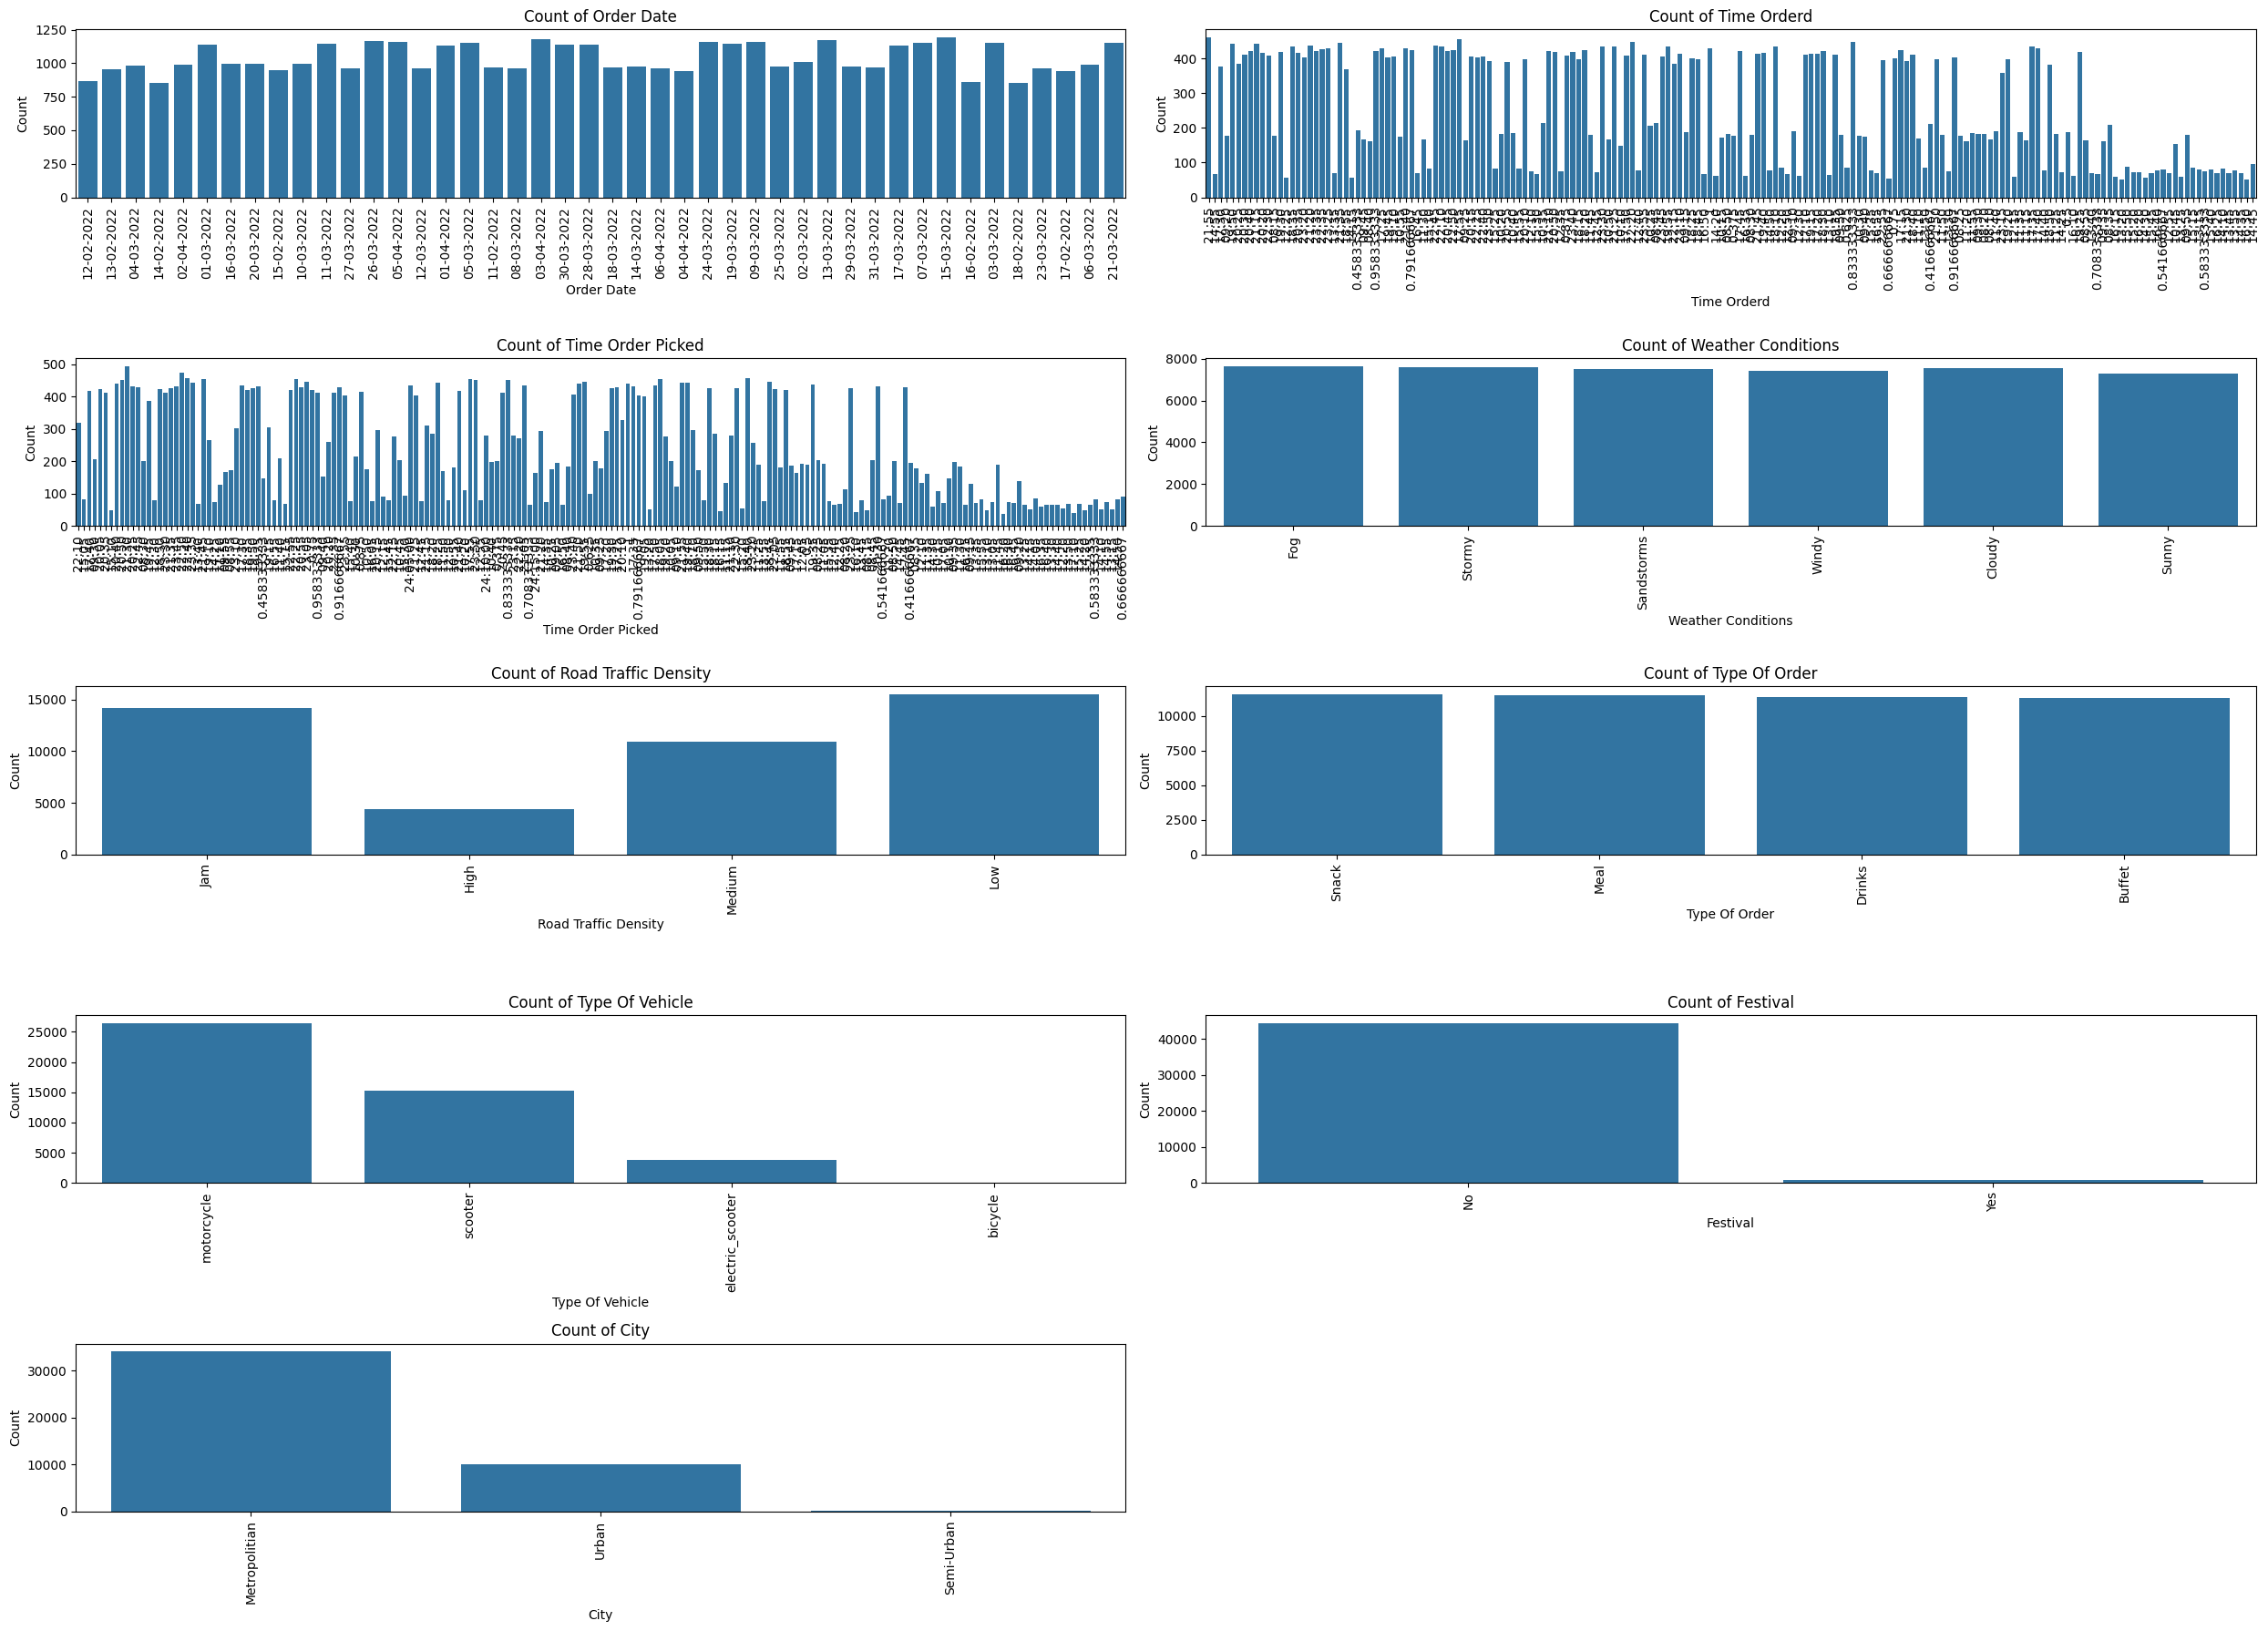

In [18]:
# Categorical columns
# Calculate number of rows and columns for subplots
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(25, 18)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Count of {col.replace('_', ' ').title()}")
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=90)

# Turn off any unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

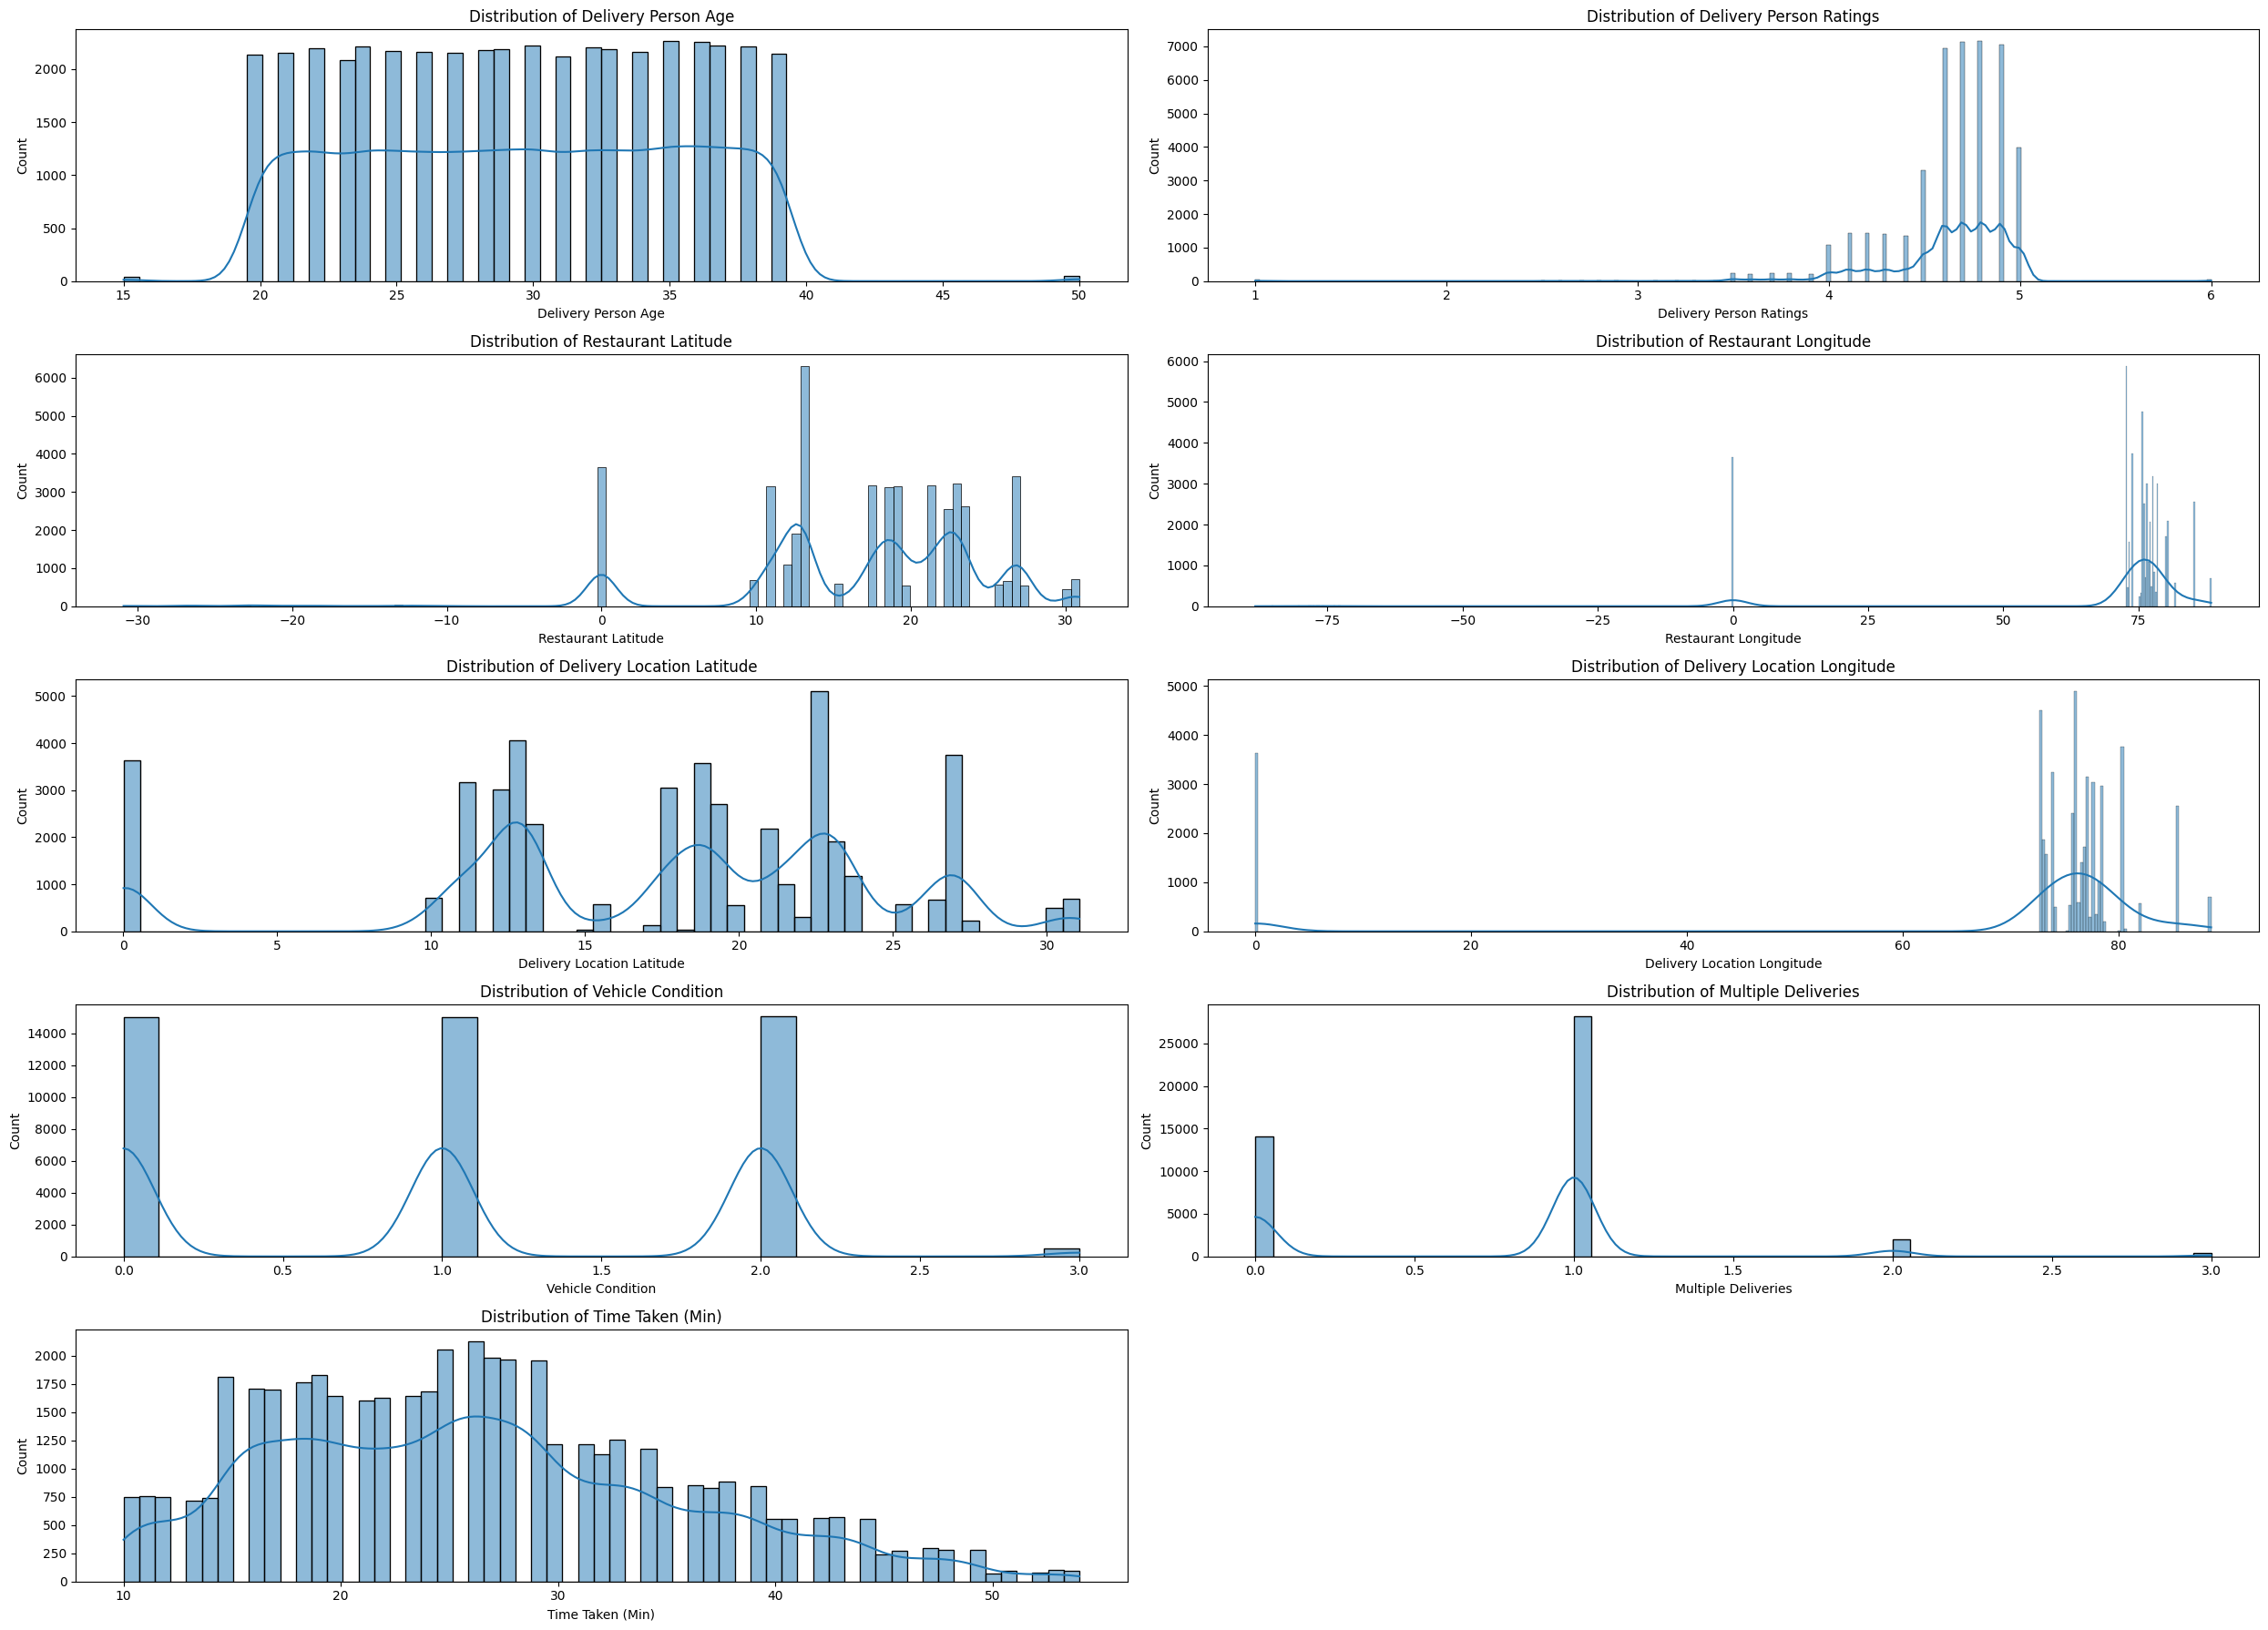

In [19]:
# Numerical columns distribution plots
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

# Create subplot grid
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(25, 18)
)
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col.replace('_', ' ').title()}")
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel("Count")

# Remove unused subplot
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Categorical / Date-Time Problems**

1. **Mixed Time Formats**
   - `Time_Orderd` and `Time_Order_picked` contain both `HH:MM` and Excel-style fractional values.
   - **Solution:** Convert them into `Order_Hour` and `Picked_Hour`.

2. **Raw Order Date**
   - `Order_Date` is stored as a raw date and is not directly useful for prediction.
   - **Solution:** Extract `Day_of_Week` and drop the original `Order_Date`.

**Numerical Data Problems**

1. **Missing Values**
   - Check and handle missing values.

2. **Delivery Person Age**
   - Values like 15 and 50 look suspicious and need validation.

3. **Geographical Coordinates**
   - Latitude and longitude contain suspicious values that need validation.

4. **Delivery Person Ratings**
   - Check whether ratings have a meaningful relationship with delivery time before deciding whether to keep them.

### Cat_cols Problems sols

In [20]:
# Problem 1: Mixed Time Formats

In [21]:
# Check the different time formats

print("Time_Orderd:")
print("HH:MM values:", df["Time_Orderd"].astype(str).str.contains(":", na=False).sum())
print("Fractional values:", (
    ~df["Time_Orderd"].astype(str).str.contains(":", na=False)
    & df["Time_Orderd"].notna()
).sum())
print("Missing:", df["Time_Orderd"].isna().sum())

print("\nTime_Order_picked:")
print("HH:MM values:", df["Time_Order_picked"].astype(str).str.contains(":", na=False).sum())
print("Fractional values:", (
    ~df["Time_Order_picked"].astype(str).str.contains(":", na=False)
    & df["Time_Order_picked"].notna()
).sum())
print("Missing:", df["Time_Order_picked"].isna().sum())

Time_Orderd:
HH:MM values: 39785
Fractional values: 4068
Missing: 1731

Time_Order_picked:
HH:MM values: 41457
Fractional values: 4127
Missing: 0


In [22]:
# Changes cell
# Convert mixed time formats into hour features

def extract_hour(x):
    if pd.isna(x):
        return np.nan

    x = str(x)

    # Handle HH:MM format
    if ":" in x:
        return int(x.split(":")[0])

    # Handle Excel fractional-day format
    try:
        return int(round(float(x) * 24)) % 24
    except:
        return np.nan


df["Order_Hour"] = df["Time_Orderd"].apply(extract_hour)
df["Picked_Hour"] = df["Time_Order_picked"].apply(extract_hour)

In [23]:
# Validation cell
# Validate the new hour features

print(df[[
    "Time_Orderd",
    "Order_Hour",
    "Time_Order_picked",
    "Picked_Hour"
]].head(10))

print("\nMissing values:")
print(df[["Order_Hour", "Picked_Hour"]].isnull().sum())

print("\nInvalid hours:")
print(df[
    (df["Order_Hour"] < 0) | (df["Order_Hour"] > 23) |
    (df["Picked_Hour"] < 0) | (df["Picked_Hour"] > 23)
].shape[0])

  Time_Orderd  Order_Hour Time_Order_picked  Picked_Hour
0       21:55        21.0             22:10           22
1       14:55        14.0             15:05           15
2       17:30        17.0             17:40           17
3       09:20         9.0             09:30            9
4       19:50        19.0             20:05           20
5       20:25        20.0             20:35           20
6       14:55        14.0             15:10           15
7       20:30        20.0             20:40           20
8       20:40        20.0             20:50           20
9       21:15        21.0             21:30           21

Missing values:
Order_Hour     1731
Picked_Hour       0
dtype: int64

Invalid hours:
880


In [24]:
# Changes cell
# Convert invalid hour 24 to midnight (0)
df["Picked_Hour"].replace(24, 0, inplace=True)

In [25]:
# Validation cell
# Validate hour ranges after correction

print("Order_Hour range:", df["Order_Hour"].min(), "to", df["Order_Hour"].max())
print("Picked_Hour range:", df["Picked_Hour"].min(), "to", df["Picked_Hour"].max())
                                                                                                
print("\nInvalid hours:")
print(
    df[
        (df["Order_Hour"] < 0) | (df["Order_Hour"] > 23) |
        (df["Picked_Hour"] < 0) | (df["Picked_Hour"] > 23)].shape[0]
)

Order_Hour range: 0.0 to 23.0
Picked_Hour range: 0 to 23

Invalid hours:
0


In [26]:
# Remove original time columns after successful conversion

df.drop(
    columns=["Time_Orderd", "Time_Order_picked"],
    inplace=True
)

In [27]:
print(df.columns.tolist())

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)', 'Order_Hour', 'Picked_Hour']


In [28]:
# Problem 2: Order_Date

In [29]:
# Check the raw date format

print("Sample dates:")
print(df["Order_Date"].head(10).to_list())

print("\nData type:")
print(df["Order_Date"].dtype)

print("\nUnique dates:", df["Order_Date"].nunique())

print("\nMissing values:", df["Order_Date"].isnull().sum())

Sample dates:
['12-02-2022', '13-02-2022', '04-03-2022', '13-02-2022', '14-02-2022', '02-04-2022', '01-03-2022', '16-03-2022', '20-03-2022', '15-02-2022']

Data type:
object

Unique dates: 44

Missing values: 0


In [30]:
# Changes cell
# Convert date to datetime and extract day of week

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="%d-%m-%Y"
)

df["Day_of_Week"] = df["Order_Date"].dt.day_name()

In [31]:
# Validation cell
# Validate date conversion and new feature

print(df[["Order_Date", "Day_of_Week"]].head(10))

print("\nData type:")
print(df["Order_Date"].dtype)

print("\nMissing values:")
print(df["Day_of_Week"].isnull().sum())

print("\nDays present:")
print(df["Day_of_Week"].value_counts())

  Order_Date Day_of_Week
0 2022-02-12    Saturday
1 2022-02-13      Sunday
2 2022-03-04      Friday
3 2022-02-13      Sunday
4 2022-02-14      Monday
5 2022-04-02    Saturday
6 2022-03-01     Tuesday
7 2022-03-16   Wednesday
8 2022-03-20      Sunday
9 2022-02-15     Tuesday

Data type:
datetime64[ns]

Missing values:
0

Days present:
Day_of_Week
Wednesday    7093
Friday       7028
Tuesday      6374
Thursday     6348
Saturday     6287
Sunday       6248
Monday       6206
Name: count, dtype: int64


In [32]:
# Remove original date column after extracting day of week

df.drop(
    columns=["Order_Date"],
    inplace=True
)

In [33]:
# Check remaining date-related column

print(df[["Day_of_Week"]].head())

  Day_of_Week
0    Saturday
1      Sunday
2      Friday
3      Sunday
4      Monday


### Num_cols problem sols

In [34]:
# Problem 1. Missing values

In [35]:
# Check missing values in numerical columns

print(df[num_cols].isnull().sum())

Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Vehicle_condition                 0
multiple_deliveries             993
Time_taken (min)                  0
dtype: int64


In [36]:
# Inspect numerical columns with missing values

missing_num_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries"
]

display(df[missing_num_cols].describe())

,Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries
count,43730.000000,43676.000000,44591.000000
mean,29.566911,4.633774,0.744635
std,5.815064,0.334744,0.572510
min,15.000000,1.000000,0.000000
25%,25.000000,4.500000,0.000000
50%,30.000000,4.700000,1.000000
75%,35.000000,4.900000,1.000000
max,50.000000,6.000000,3.000000


In [37]:
# Check value distributions

for col in missing_num_cols:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print(df[col].value_counts(dropna=False).sort_index())


Delivery_person_Age
Delivery_person_Age
15.0      38
20.0    2136
21.0    2153
22.0    2194
23.0    2086
24.0    2210
25.0    2174
26.0    2159
27.0    2150
28.0    2179
29.0    2191
30.0    2226
31.0    2120
32.0    2201
33.0    2186
34.0    2165
35.0    2261
36.0    2260
37.0    2226
38.0    2218
39.0    2144
50.0      53
NaN     1854
Name: count, dtype: int64

Delivery_person_Ratings
Delivery_person_Ratings
1.0      38
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3.0       6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4.0    1077
4.1    1430
4.2    1418
4.3    1409
4.4    1360
4.5    3302
4.6    6938
4.7    7140
4.8    7146
4.9    7040
5.0    3996
6.0      53
NaN    1908
Name: count, dtype: int64

multiple_deliveries
multiple_deliveries
0.0    14094
1.0    28151
2.0     1985
3.0      361
NaN      993
Name: count, dtype: int64


In [38]:
# Fill missing numerical values with their respective medians

df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median(),
    inplace=True
)

df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median(),
    inplace=True
)

df["multiple_deliveries"].fillna(
    df["multiple_deliveries"].median(),
    inplace=True
)

In [39]:
# Validate numerical missing values after imputation

print(df[num_cols].isnull().sum())

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Vehicle_condition              0
multiple_deliveries            0
Time_taken (min)               0
dtype: int64


In [40]:
# problem 2: Suspicious rating values(6.0)

In [41]:
# Check relationship between delivery ratings and delivery time

rating_effect = df.groupby("Delivery_person_Ratings")["Time_taken (min)"].agg(
    ["count", "mean", "median"]
)

display(rating_effect)

,count,mean,median
Delivery_person_Ratings,,,
1.0,38,26.000000,26.5
2.5,20,37.300000,35.5
2.6,22,38.590909,39.0
2.7,22,35.863636,36.5
2.8,19,36.631579,37.0
2.9,19,38.526316,39.0
3.0,6,32.666667,32.5
3.1,29,36.551724,35.0
3.2,29,36.344828,36.0


In [42]:
# Inspect suspicious rating values

suspicious_ratings = df[
    (df["Delivery_person_Ratings"] == 1.0) |
    (df["Delivery_person_Ratings"] == 6.0)
]

print("Suspicious rating rows:", suspicious_ratings.shape[0])

display(
    suspicious_ratings[
        ["Delivery_person_Ratings", "Delivery_person_Age", "Time_taken (min)"]
    ].head(20)
)

Suspicious rating rows: 91


,Delivery_person_Ratings,Delivery_person_Age,Time_taken (min)
2378,1.0,15.0,15
2896,1.0,15.0,29
2942,1.0,15.0,20
3577,6.0,50.0,25
4705,6.0,50.0,27
5160,6.0,50.0,20
5353,6.0,50.0,18
5642,6.0,50.0,20
5893,1.0,15.0,25
6385,6.0,50.0,20


In [43]:
'''
Age 15  → Rating 1.0
Age 50  → Rating 6.0
'''

'\nAge 15  → Rating 1.0\nAge 50  → Rating 6.0\n'

In [44]:
# Checking whether the suspicious age and rating values always occur together

print(
    pd.crosstab(
        df["Delivery_person_Age"],
        df["Delivery_person_Ratings"]
    ).loc[[15, 50]]
)

Delivery_person_Ratings  1.0  2.5  2.6  2.7  2.8  2.9  3.0  3.1  3.2  3.3  \
Delivery_person_Age                                                         
15.0                      38    0    0    0    0    0    0    0    0    0   
50.0                       0    0    0    0    0    0    0    0    0    0   

Delivery_person_Ratings  ...  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.0  6.0  
Delivery_person_Age      ...                                                    
15.0                     ...    0    0    0    0    0    0    0    0    0    0  
50.0                     ...    0    0    0    0    0    0    0    0    0   53  

[2 rows x 28 columns]


Data-quality observation: Age values 15 and 50 consistently correspond to ratings 1 and 6 respectively, suggesting a systematic anomaly in the source dataset. These observations were retained rather than manually corrected because their underlying encoding cannot be established with certainty.

In [45]:
# Rebuild categorical and numerical column lists

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("\nNumerical columns:", num_cols)

Categorical columns: ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Day_of_Week']

Numerical columns: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries', 'Time_taken (min)', 'Order_Hour', 'Picked_Hour']


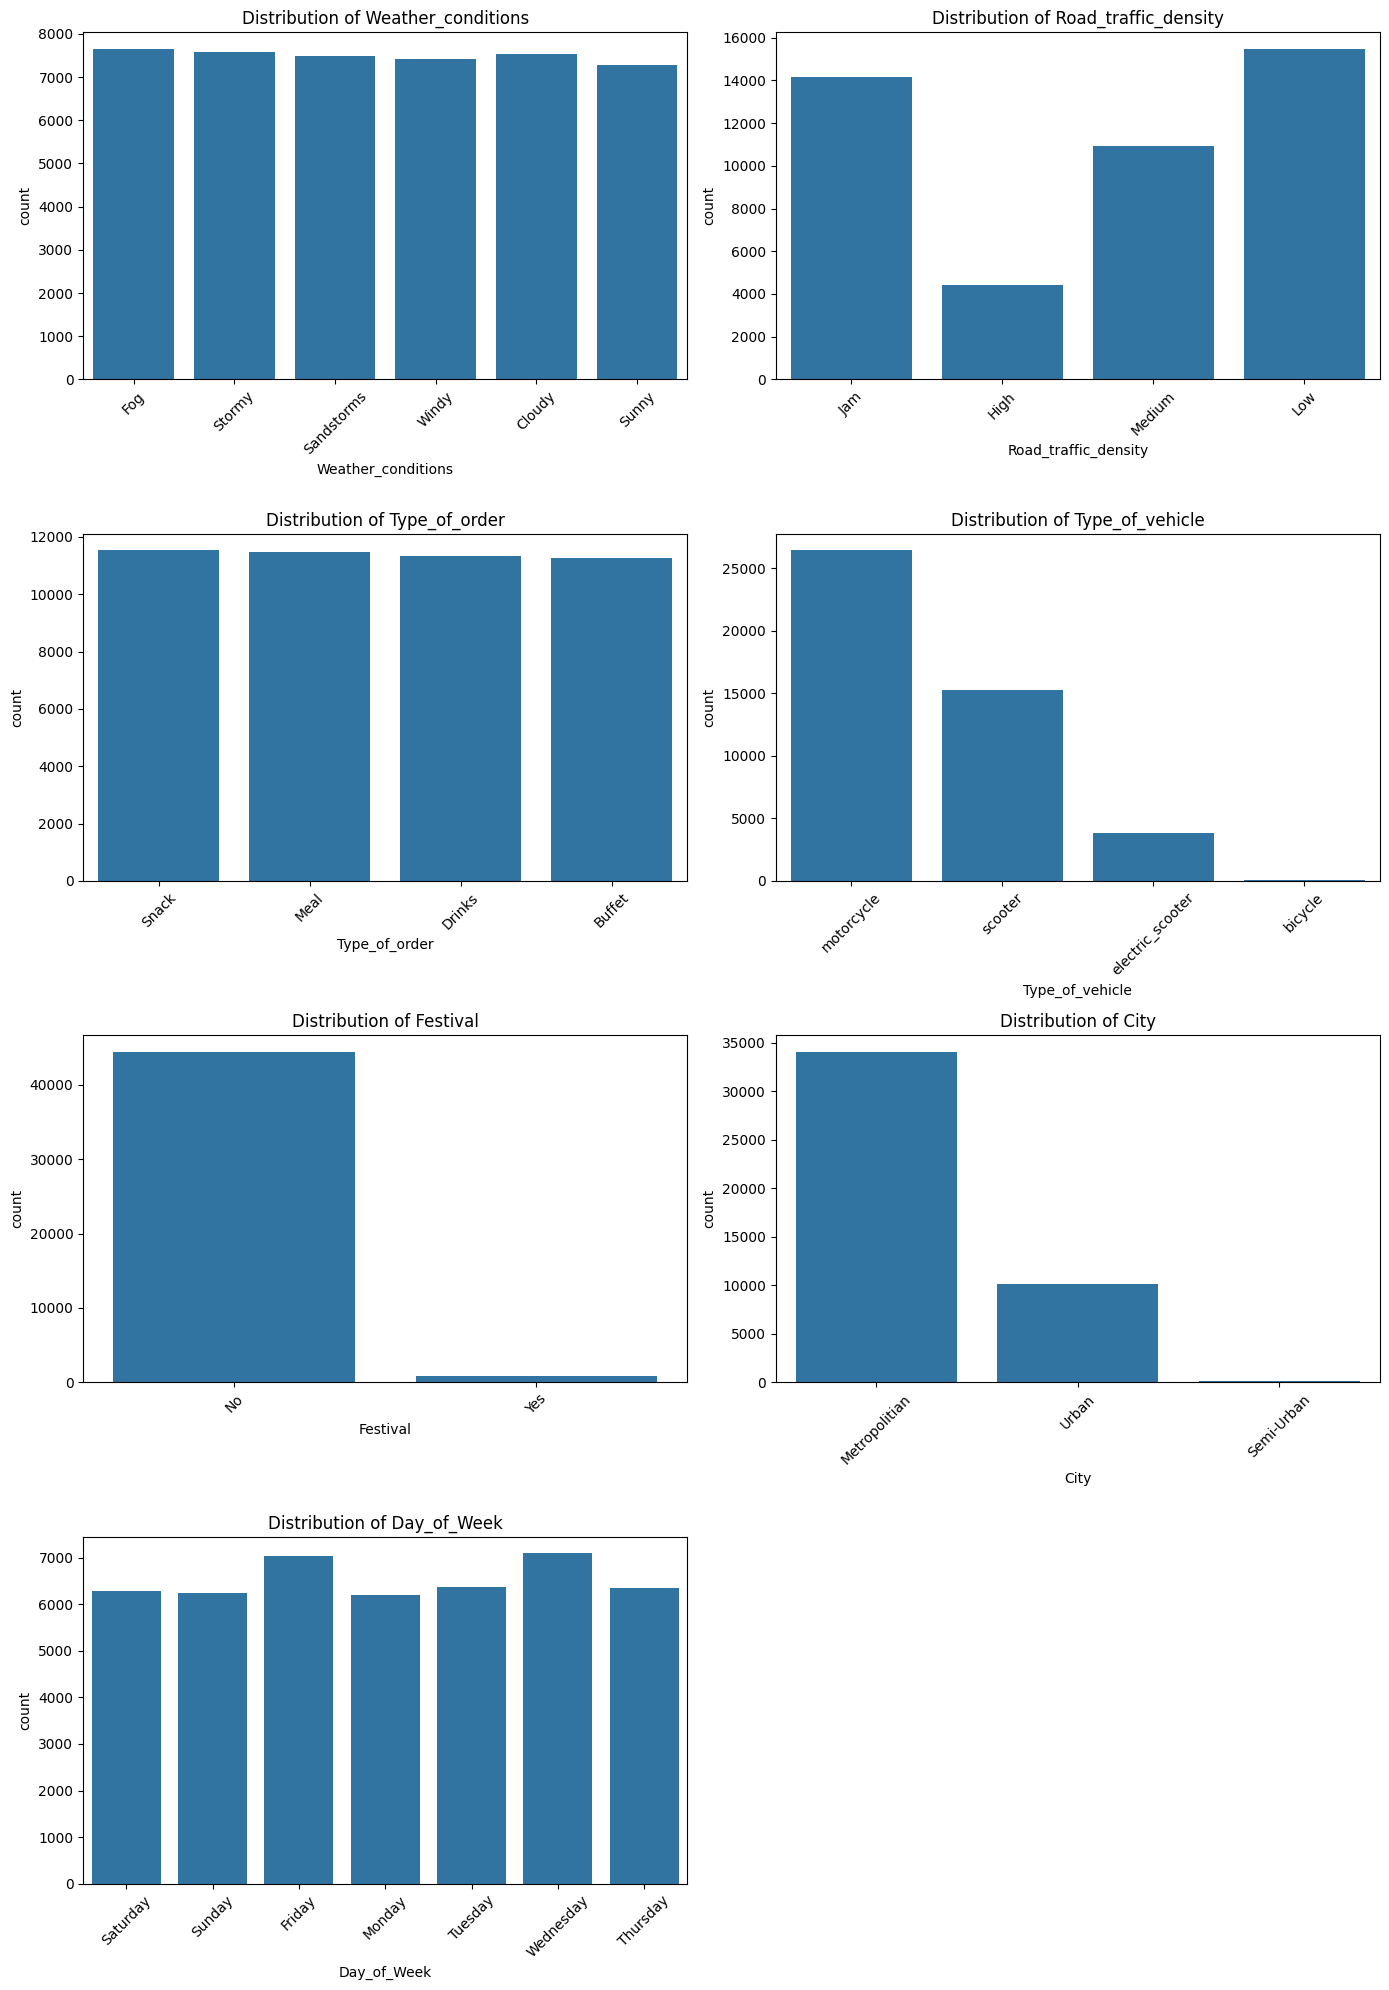

In [46]:
# Final categorical distribution plots

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=45)

for i in range(len(cat_cols), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

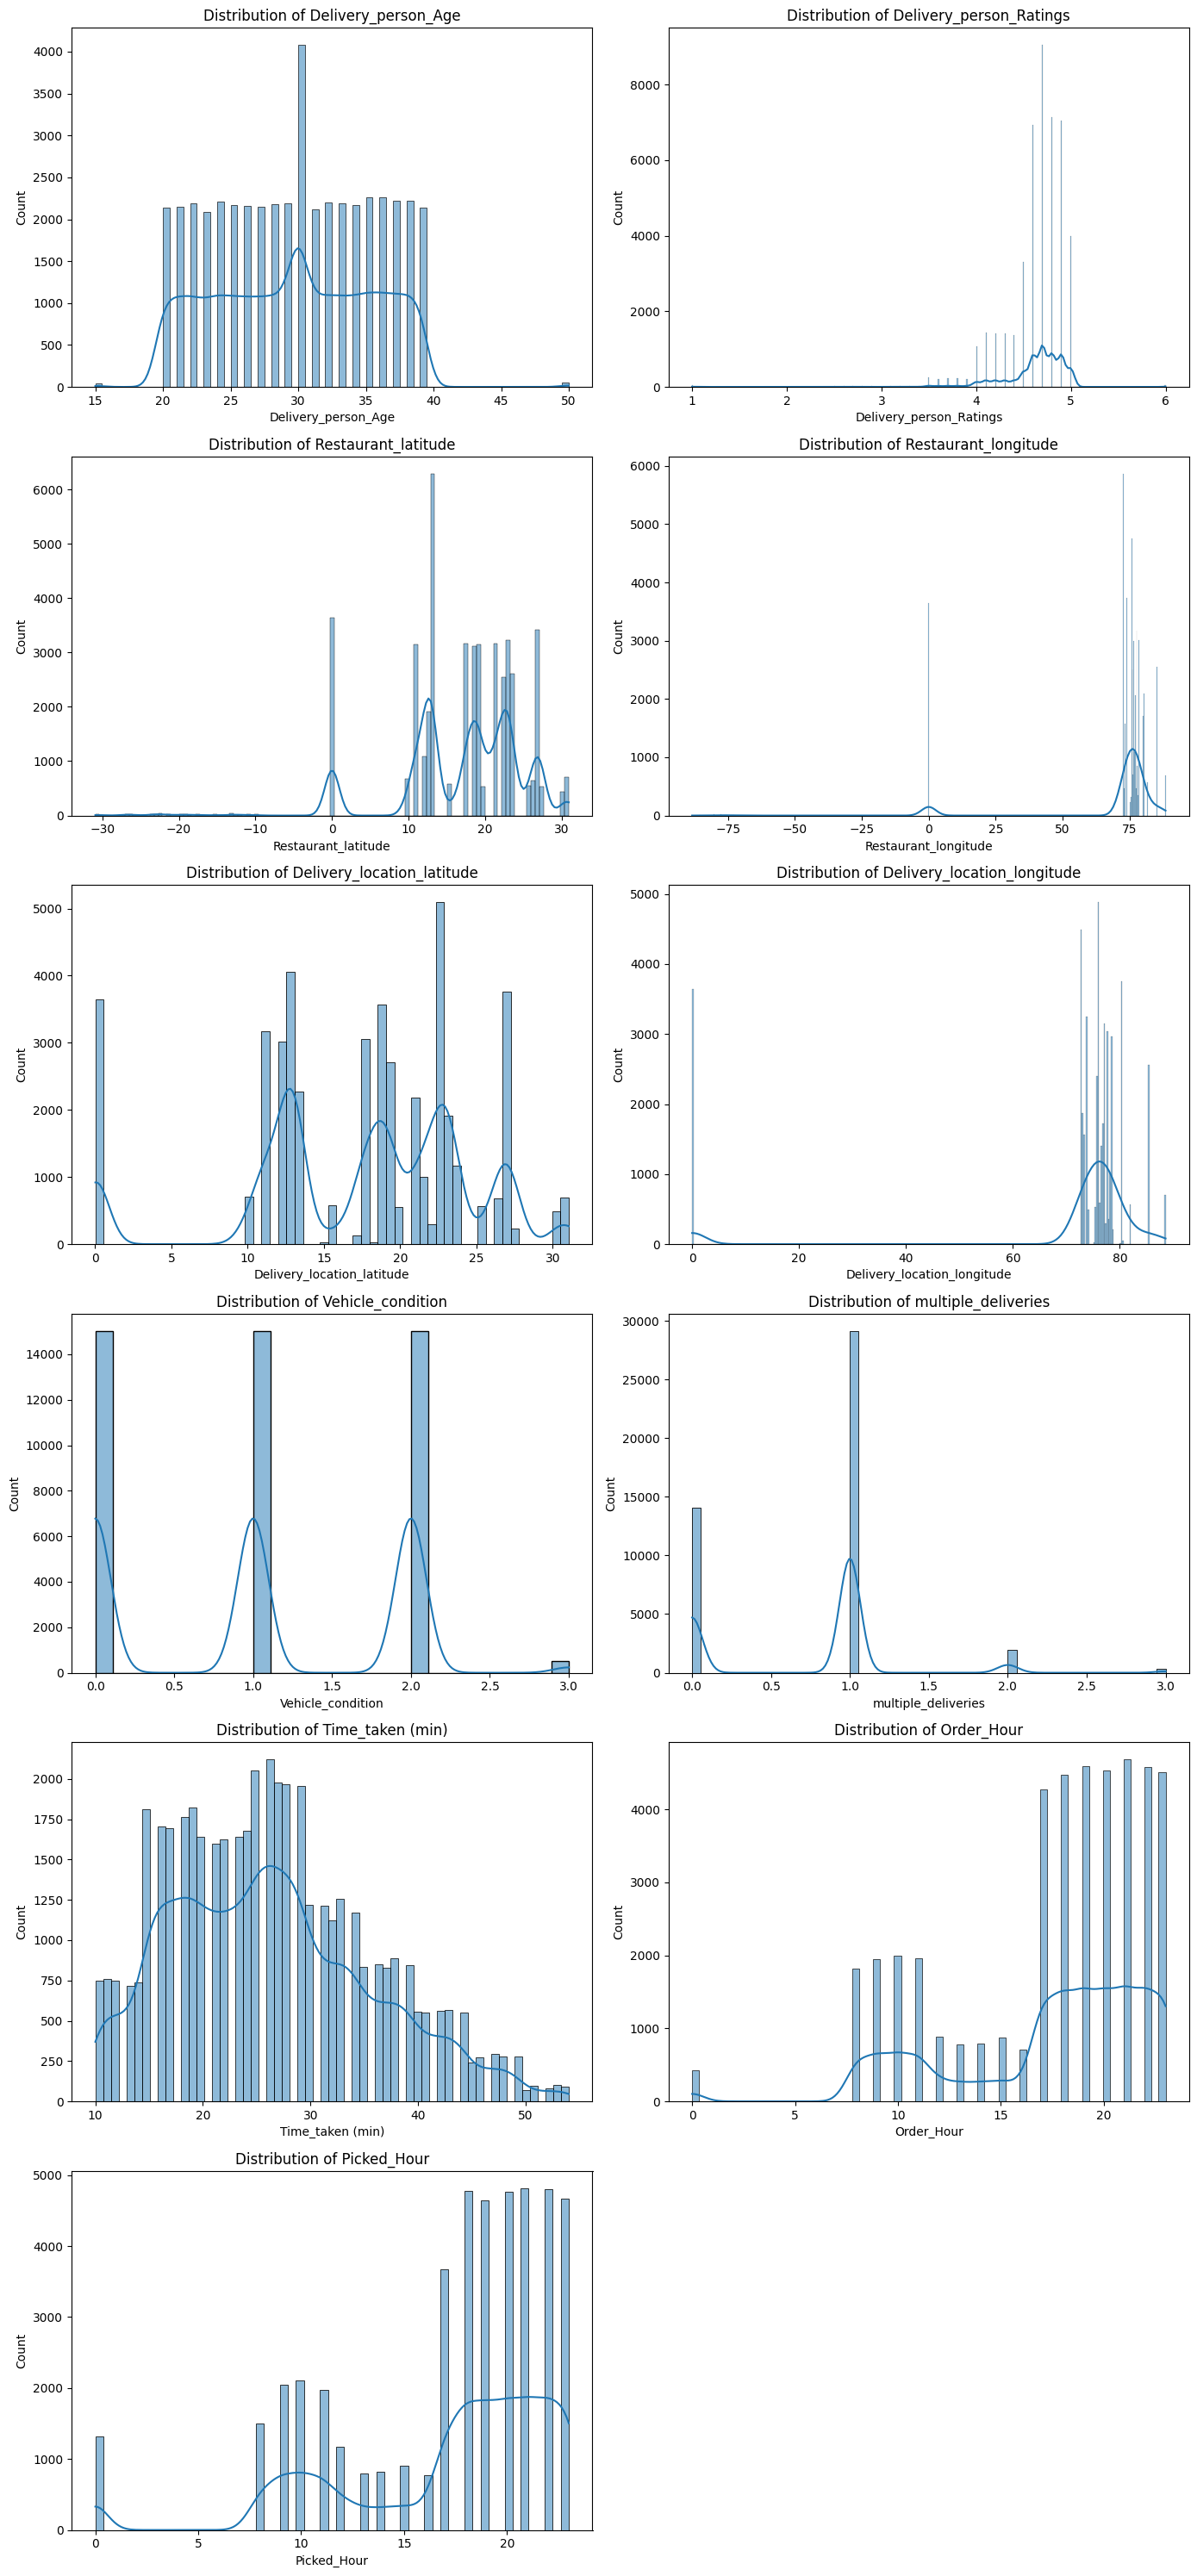

In [47]:
# Final numerical distribution plots

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")

for i in range(len(num_cols), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

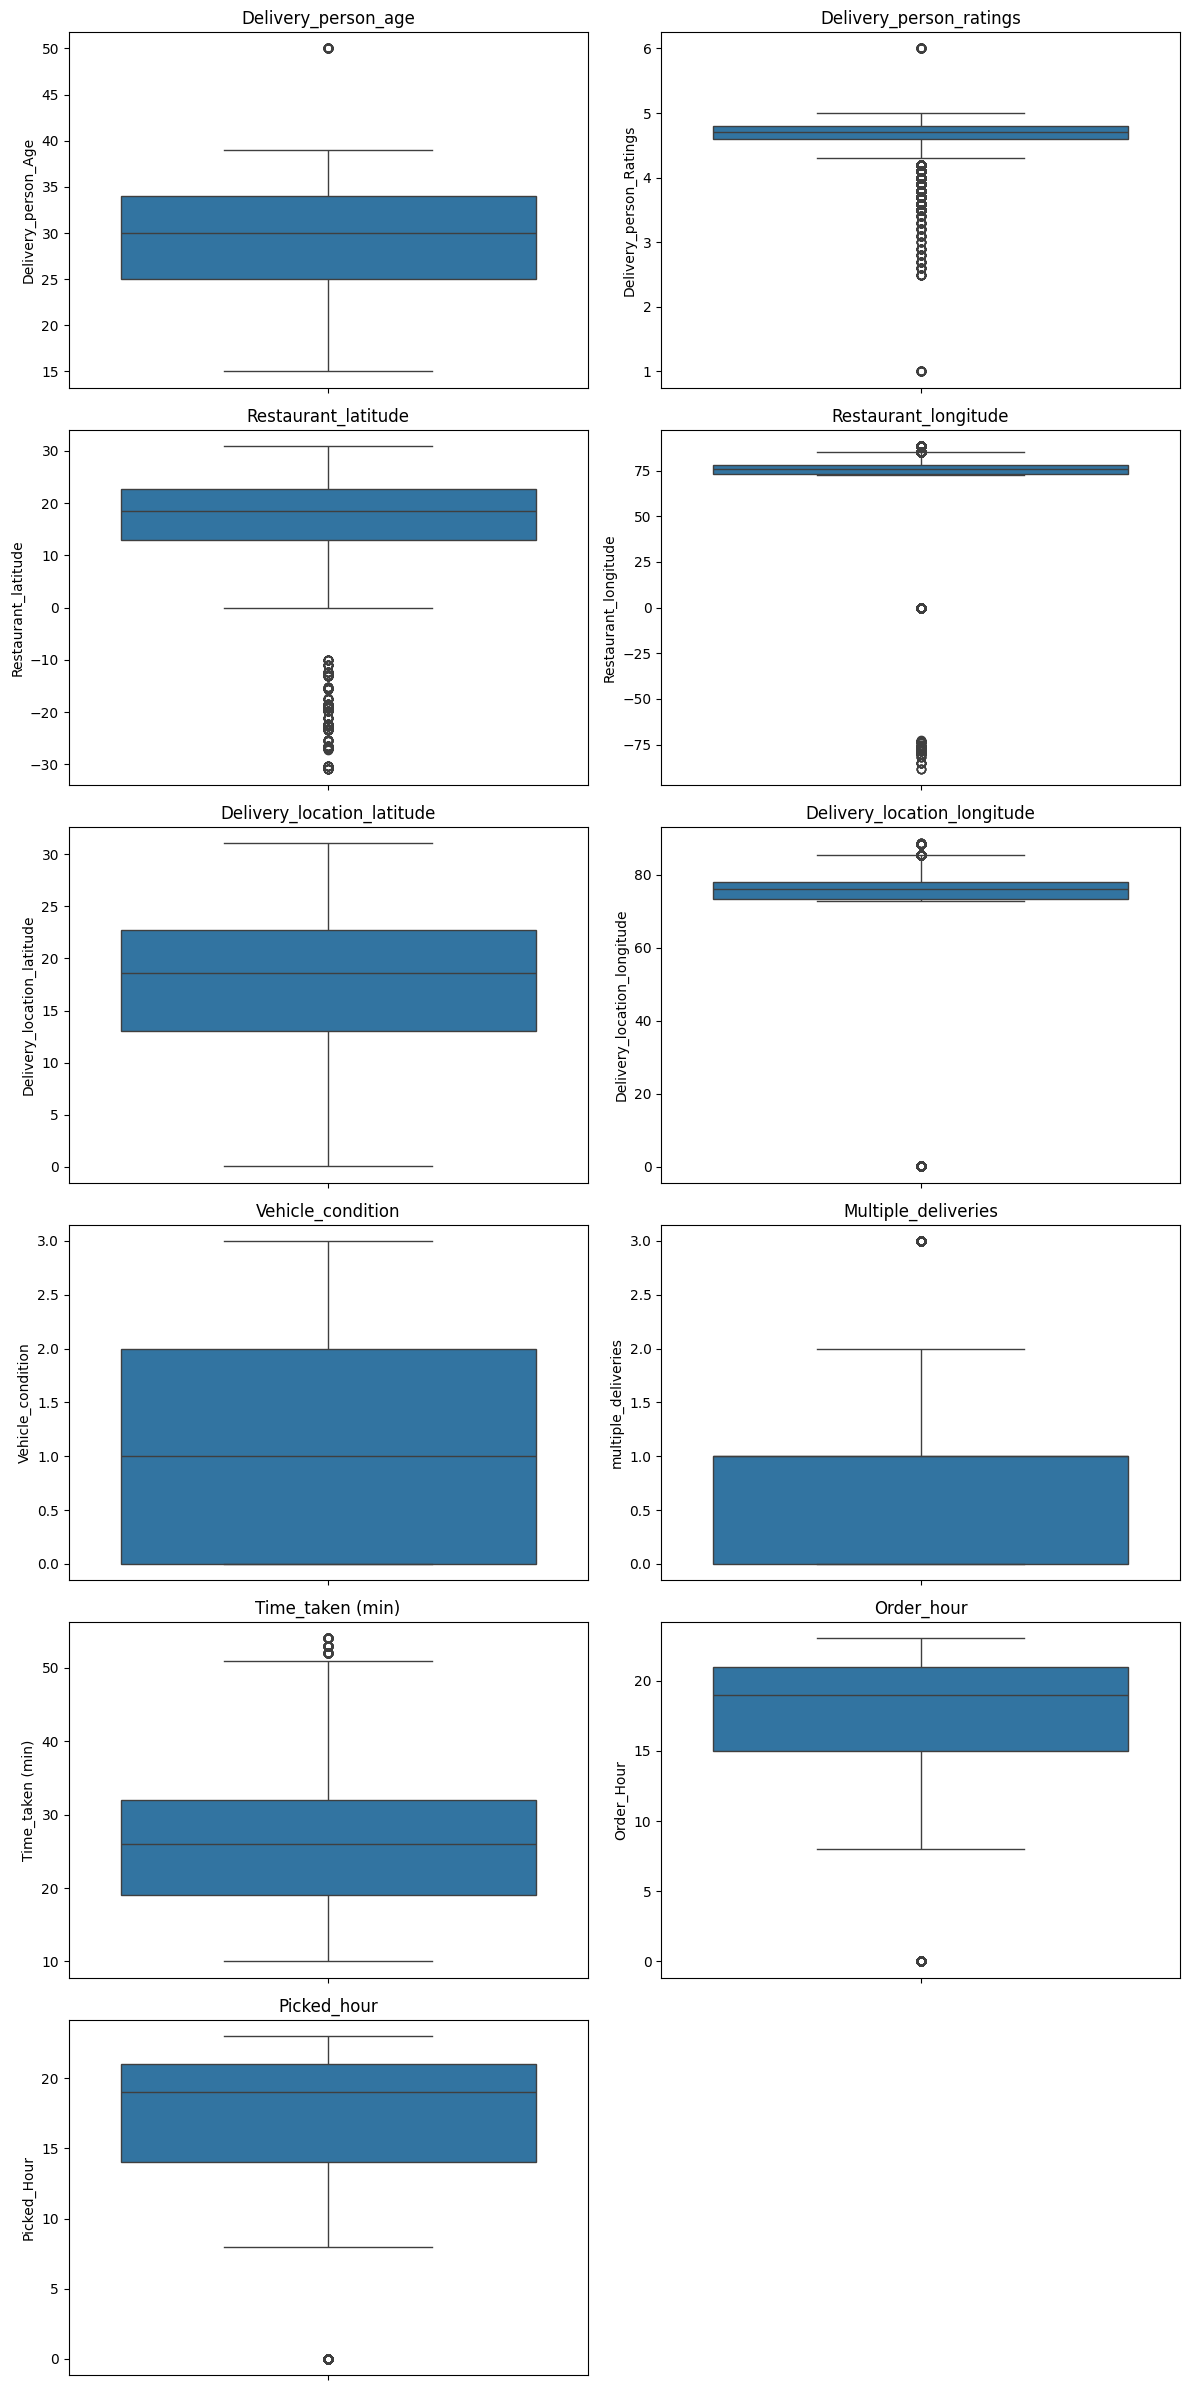

In [48]:
# Box plots for numerical columns

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col.capitalize()}")

for i in range(len(num_cols), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

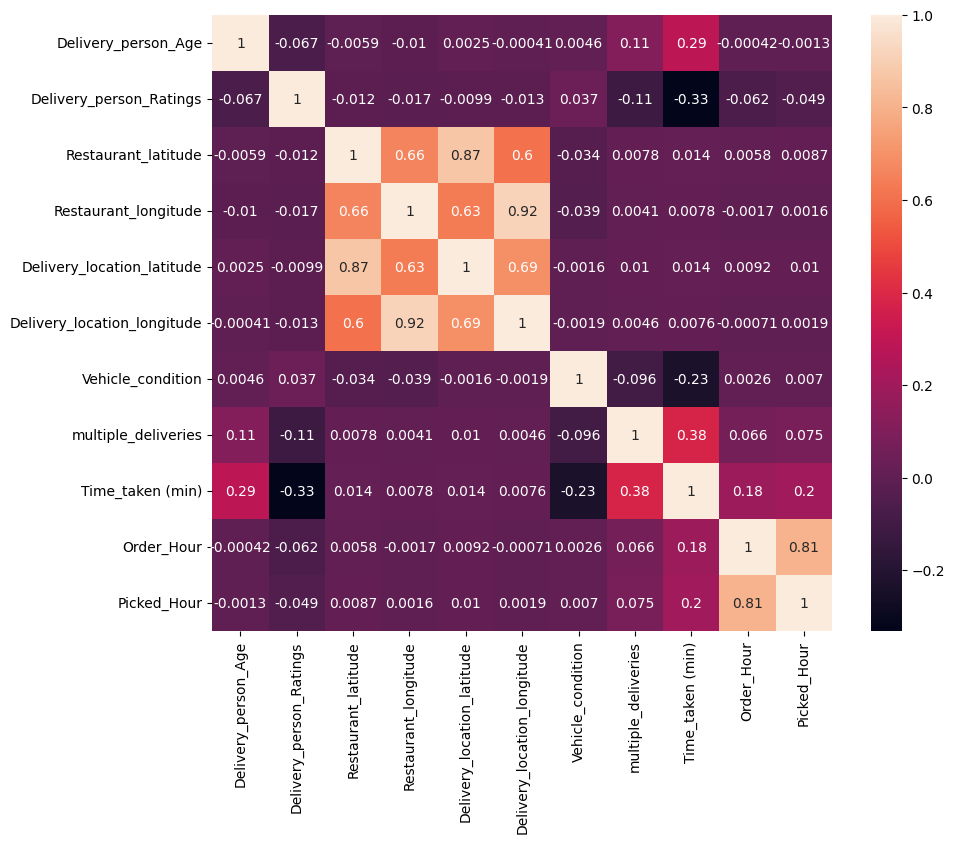

In [49]:
# heatmap for co-relation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [50]:
'''
Strong relationship with target(time)

multiple_deliveries      +0.38
Delivery_person_Ratings  -0.33
Delivery_person_Age      +0.29
Vehicle_condition        -0.23
Picked_Hour              +0.20
Order_Hour               +0.18
'''

'\nStrong relationship with target(time)\n\nmultiple_deliveries      +0.38\nDelivery_person_Ratings  -0.33\nDelivery_person_Age      +0.29\nVehicle_condition        -0.23\nPicked_Hour              +0.20\nOrder_Hour               +0.18\n'

In [51]:
# Check remaining missing values

print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                        228
City                           1200
Time_taken (min)                  0
Order_Hour                     1731
Picked_Hour                       0
Day_of_Week                       0
dtype: int64

Total missing values: 4376


In [52]:
# Remove rows with remaining missing values

df.dropna(inplace=True)

In [53]:
# Reset index after removing incomplete rows

df.reset_index(drop=True, inplace=True)

In [54]:
# Validate final cleaned dataset

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Shape: (42508, 18)

Missing values:
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
Order_Hour                     0
Picked_Hour                    0
Day_of_Week                    0
dtype: int64

Total missing values: 0


Final Missing Value Handling

- Numerical missing values in `Delivery_person_Age`, `Delivery_person_Ratings`, and `multiple_deliveries` were handled using median imputation.
- Remaining rows with missing categorical values or missing `Order_Hour` were removed.
- The dataset was re-indexed after removing incomplete rows.
- Final dataset contains no missing values.

In [55]:
# Final data cleaning check

print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)
df

Shape: (42508, 18)
Duplicate rows: 0

Data types:
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
Order_Hour                     float64
Picked_Hour                      int64
Day_of_Week                     object
dtype: object


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Order_Hour,Picked_Hour,Day_of_Week
0,36.0,4.2,30.327968,78.046106,30.397968,78.116106,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,21.0,22,Saturday
1,21.0,4.7,10.003064,76.307589,10.043064,76.347589,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,14.0,15,Sunday
2,23.0,4.7,18.562450,73.916619,18.652450,74.006619,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,17.0,17,Friday
3,34.0,4.3,30.899584,75.809346,30.919584,75.829346,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,9.0,9,Sunday
4,24.0,4.7,26.463504,80.372929,26.593504,80.502929,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.0,20,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42503,30.0,4.8,26.902328,75.794257,26.912328,75.804257,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,11.0,11,Thursday
42504,21.0,4.6,0.000000,0.000000,0.070000,0.070000,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36,19.0,20,Wednesday
42505,30.0,4.9,13.022394,80.242439,13.052394,80.272439,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,23.0,0,Friday
42506,20.0,4.7,11.001753,76.986241,11.041753,77.026241,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,13.0,13,Monday


## EDA

In [56]:
'''
Strong relationship with target(time)

multiple_deliveries      +0.38
Delivery_person_Ratings  -0.33
Delivery_person_Age      +0.29
Vehicle_condition        -0.23
Picked_Hour              +0.20
Order_Hour               +0.18
'''

'\nStrong relationship with target(time)\n\nmultiple_deliveries      +0.38\nDelivery_person_Ratings  -0.33\nDelivery_person_Age      +0.29\nVehicle_condition        -0.23\nPicked_Hour              +0.20\nOrder_Hour               +0.18\n'

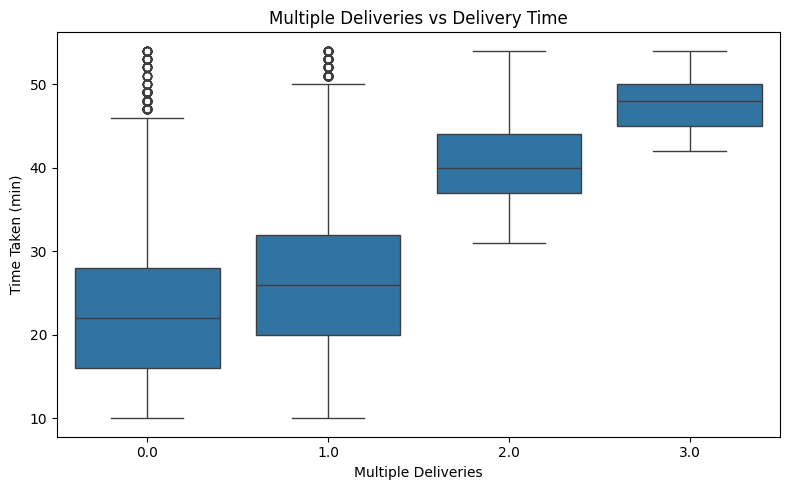

In [57]:
# Multiple deliveries vs delivery time

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="multiple_deliveries",
    y="Time_taken (min)"
)

plt.title("Multiple Deliveries vs Delivery Time")
plt.xlabel("Multiple Deliveries")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [58]:
"""
In this dataset, multiple_deliveries represents the number of deliveries/orders being handled together.
So as the number of multiple deliveries increases, delivery time rises substantially.

This is also consistent with your correlation"""

'\nIn this dataset, multiple_deliveries represents the number of deliveries/orders being handled together.\nSo as the number of multiple deliveries increases, delivery time rises substantially.\n\nThis is also consistent with your correlation'

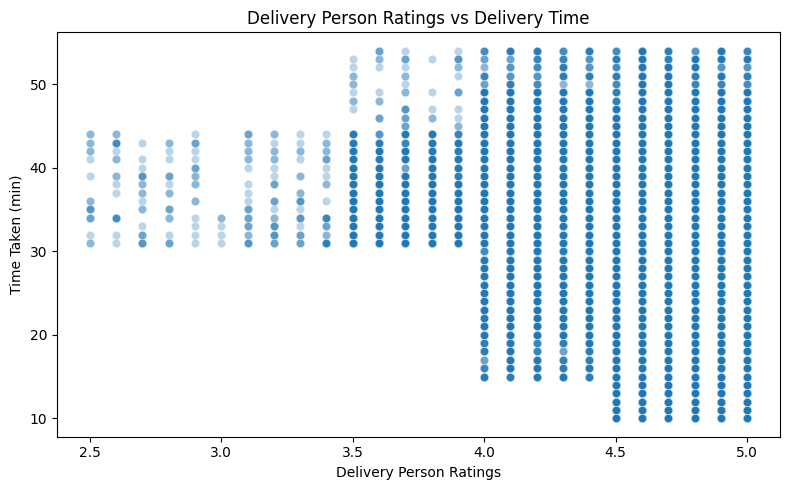

In [59]:
# Delivery person ratings vs delivery time

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Delivery_person_Ratings",
    y="Time_taken (min)",
    alpha=0.3
)

plt.title("Delivery Person Ratings vs Delivery Time")
plt.xlabel("Delivery Person Ratings")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [60]:
"""
 Higher rating
       ↓
 Lower delivery time
 """

'\n Higher rating\n       ↓\n Lower delivery time\n '

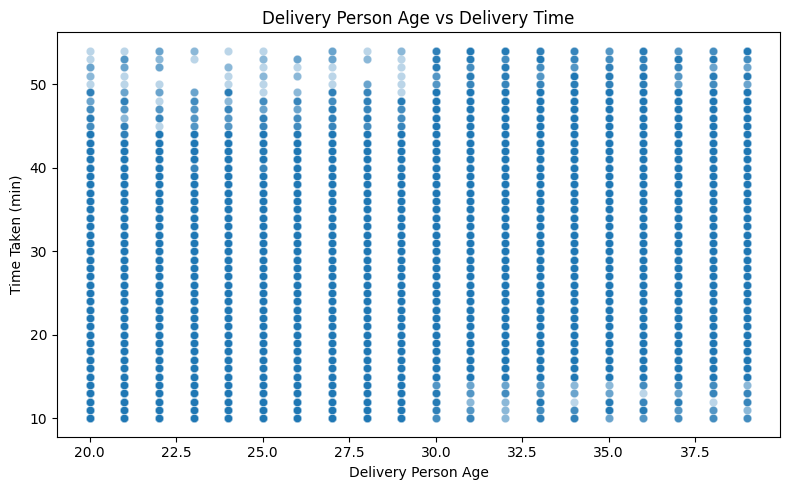

In [61]:
# Delivery person age vs delivery time

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Delivery_person_Age",
    y="Time_taken (min)",
    alpha=0.3
)

plt.title("Delivery Person Age vs Delivery Time")
plt.xlabel("Delivery Person Age")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [62]:
 """Older delivery persons tend to have somewhat higher delivery times in this dataset, 
but the relationship is weak enough that age alone is not a strong predictor"""

'Older delivery persons tend to have somewhat higher delivery times in this dataset, \nbut the relationship is weak enough that age alone is not a strong predictor'

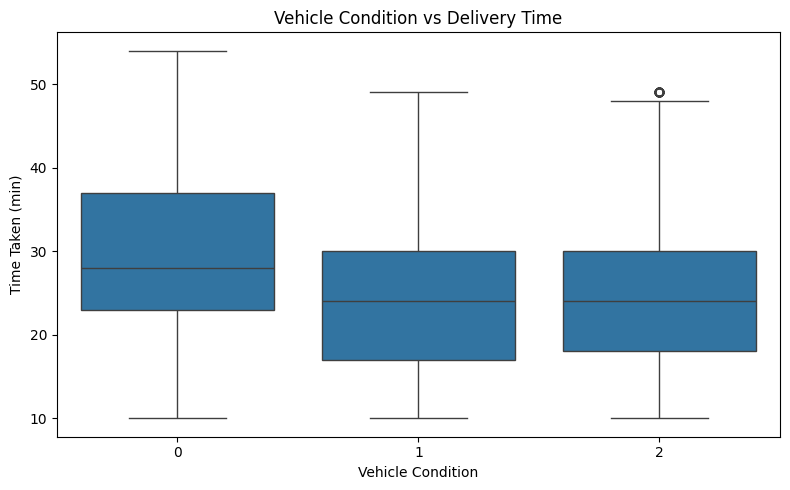

In [63]:
# Vehicle condition vs delivery time

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Vehicle_condition",
    y="Time_taken (min)"
)

plt.title("Vehicle Condition vs Delivery Time")
plt.xlabel("Vehicle Condition")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [64]:
"""Vehicle condition shows a moderate negative relationship with delivery time.
Orders associated with lower vehicle-condition values tend to have higher delivery
times, while better vehicle conditions are generally associated with shorter
delivery times."""

'Vehicle condition shows a moderate negative relationship with delivery time.\nOrders associated with lower vehicle-condition values tend to have higher delivery\ntimes, while better vehicle conditions are generally associated with shorter\ndelivery times.'

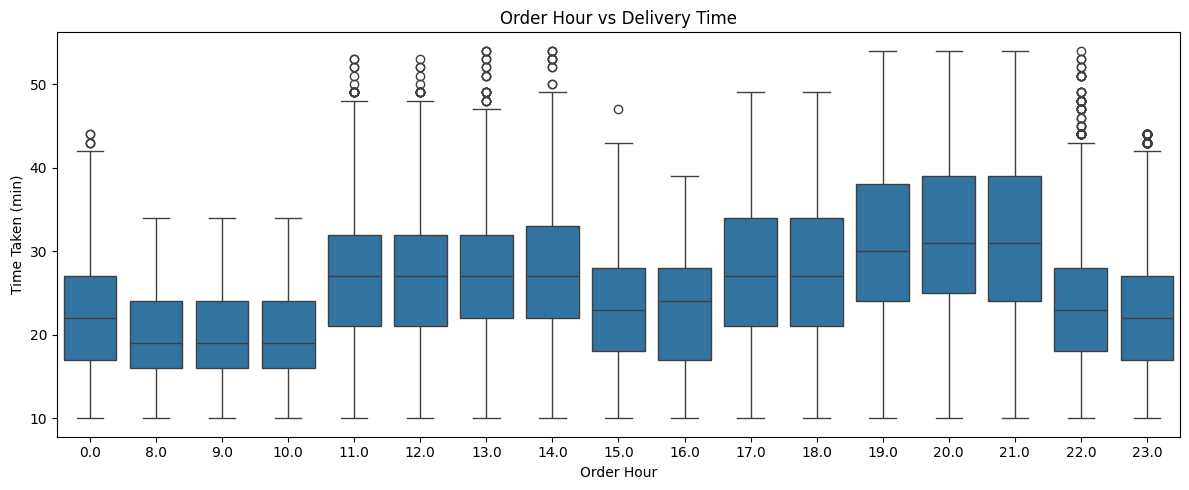

In [65]:
# Order hour vs delivery time

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="Order_Hour",
    y="Time_taken (min)"
)

plt.title("Order Hour vs Delivery Time")
plt.xlabel("Order Hour")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [66]:
"""Delivery time varies noticeably across different order hours. Delivery times are
generally higher during afternoon and evening periods, with the highest median
delivery times observed around 19:00–21:00. This suggests that time of day may
capture changes in traffic and delivery demand that affect ETA."""

'Delivery time varies noticeably across different order hours. Delivery times are\ngenerally higher during afternoon and evening periods, with the highest median\ndelivery times observed around 19:00–21:00. This suggests that time of day may\ncapture changes in traffic and delivery demand that affect ETA.'

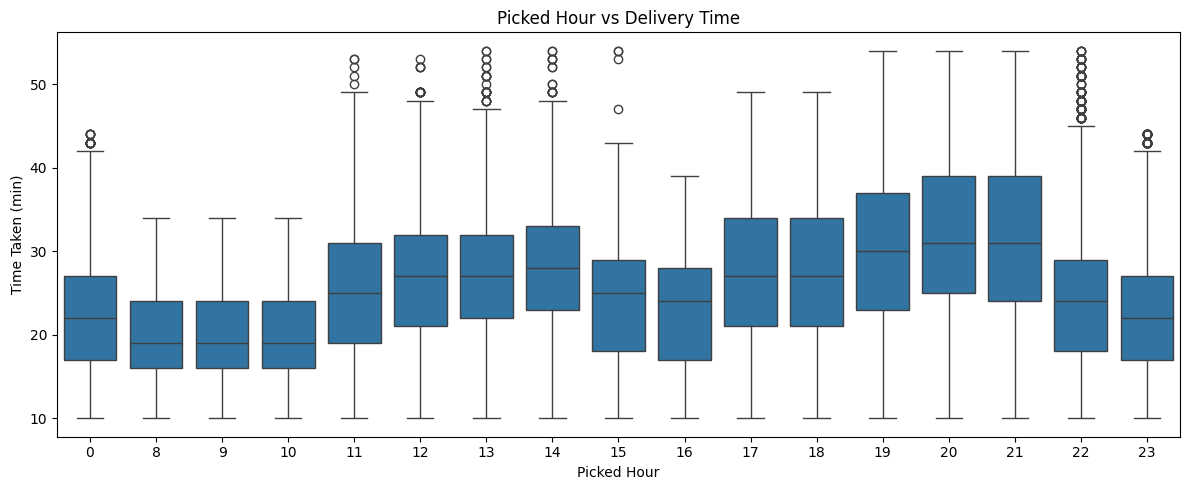

In [67]:
# Picked hour vs delivery time

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="Picked_Hour",
    y="Time_taken (min)"
)

plt.title("Picked Hour vs Delivery Time")
plt.xlabel("Picked Hour")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [68]:
# similar to order hour

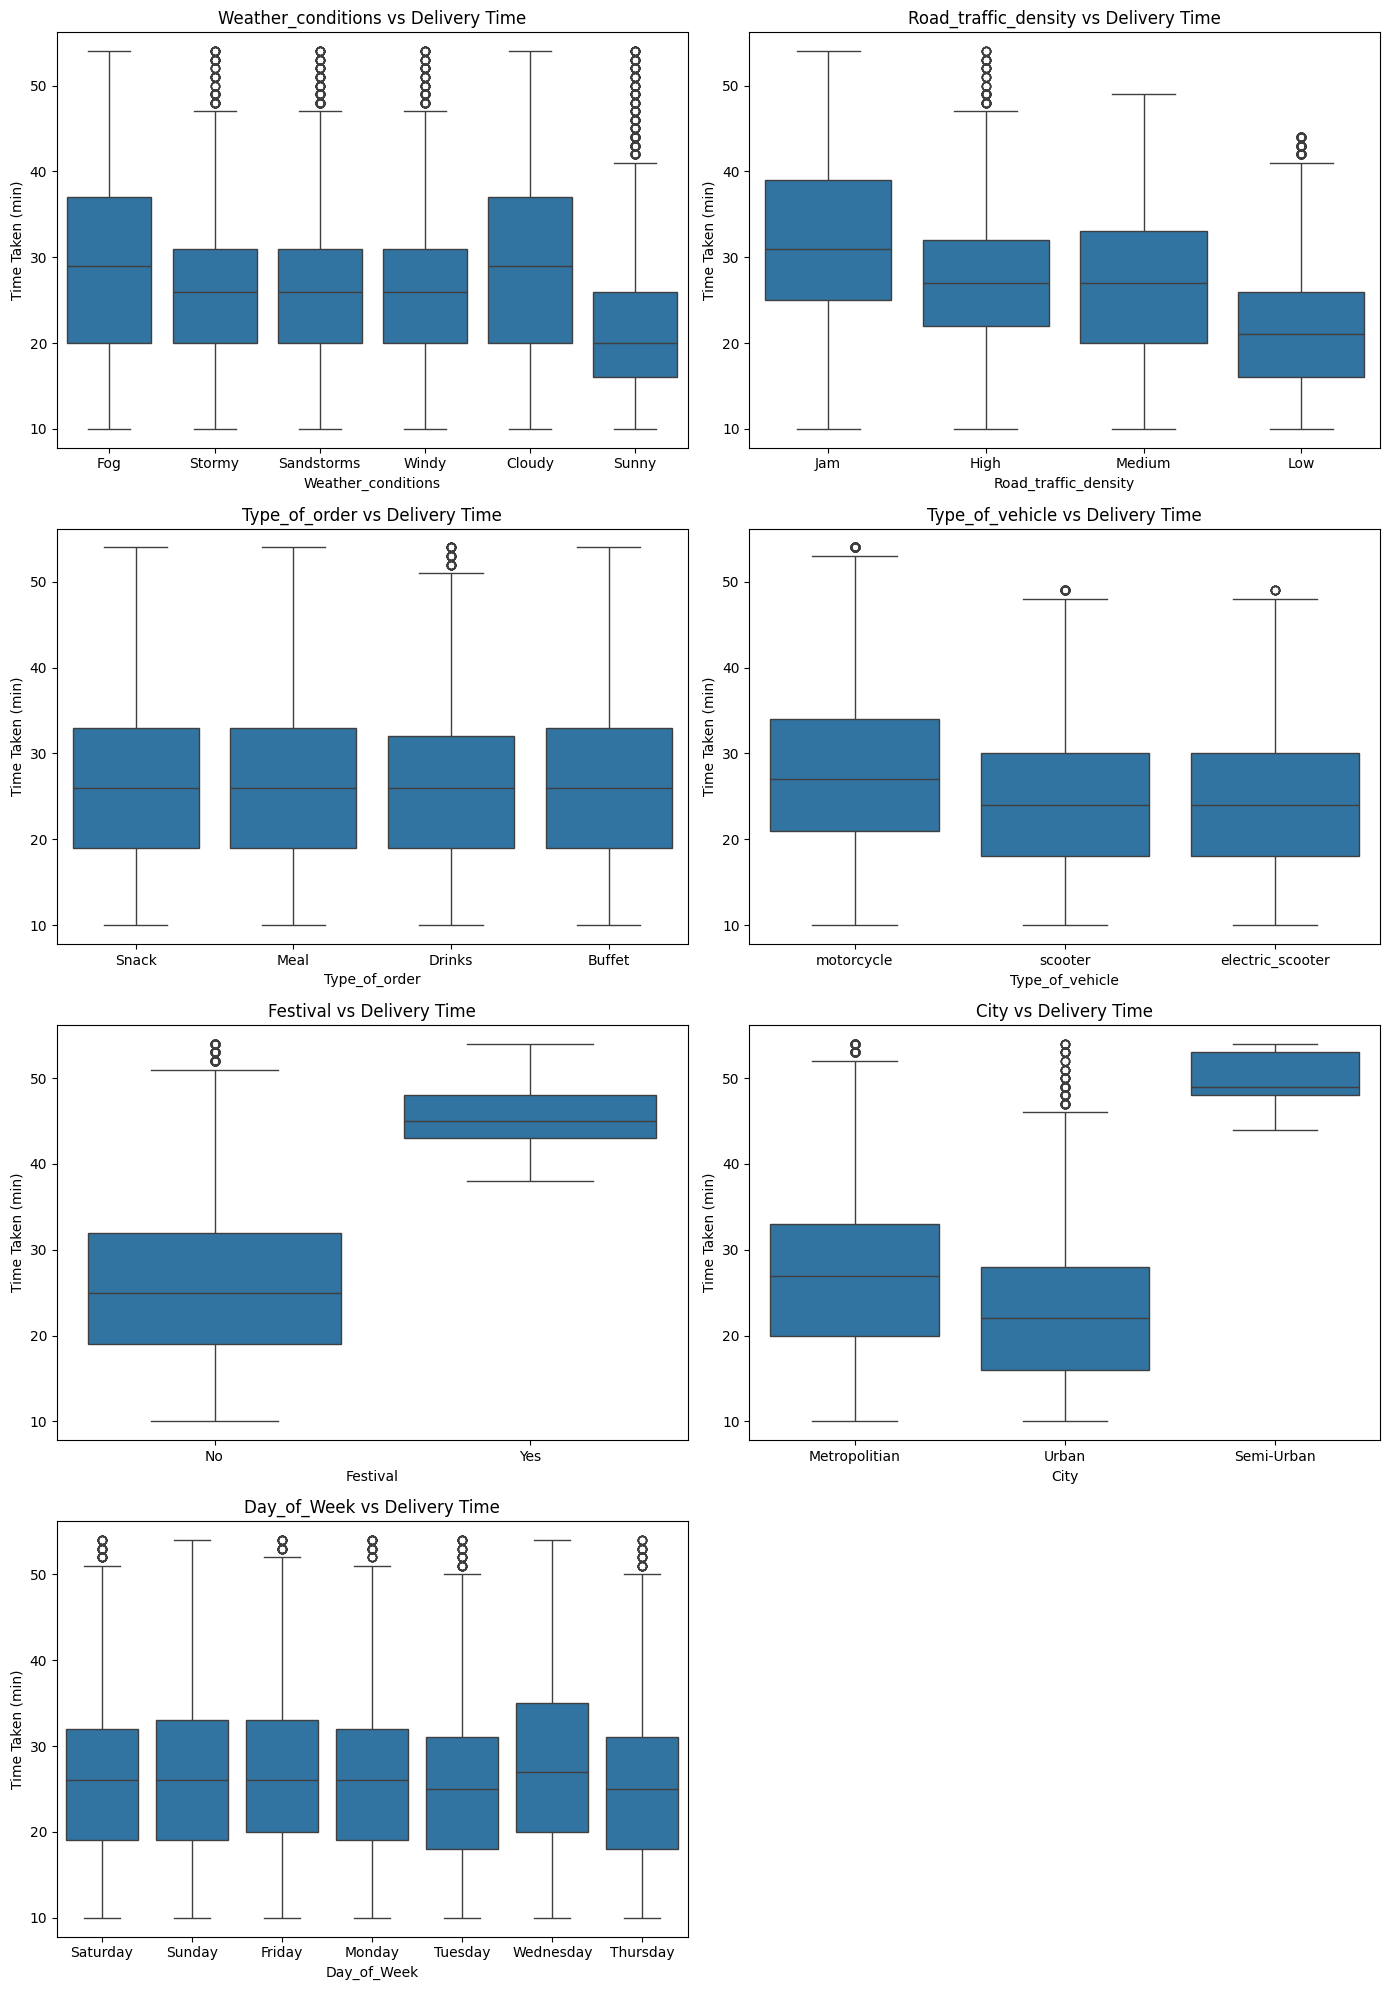

In [69]:
# Categorical features vs delivery time

cat_target_cols = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "Day_of_Week"
]

n_cols = 2
n_rows = (len(cat_target_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(14, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_target_cols):
    sns.boxplot(
        data=df,
        x=col,
        y="Time_taken (min)",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Delivery Time")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Time Taken (min)")

for i in range(len(cat_target_cols), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

**Categorical Features vs Delivery Time: Observations**
1. Weather: Sunny has the lowest median delivery time, while Fog/Cloudy are higher.
2. Traffic: Jam has the highest delivery time; Low has the lowest.
3. Type of order: Very little difference across order types.
4. Vehicle type: Motorcycle shows slightly higher delivery times.
5. Festival: Festival orders have much higher delivery times.
6. City: Semi-Urban has the highest delivery time, while Urban has the lowest.
7. Day of week: Differences are relatively small, with Wednesday slightly higher.

Overall: Traffic, festival, weather, and city show the clearest differences in delivery time.

## Feature Engineering

In [70]:
# Use the Haversine formula because our coordinates are latitude/longitude.

In [71]:
# Calculate distance between restaurant and delivery location

from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


df["distance_km"] = df.apply(
    lambda row: haversine_distance(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ),
    axis=1
)

In [72]:
# Validate distance feature

print(df["distance_km"].describe())

print("\nMissing values:", df["distance_km"].isnull().sum())

count    42508.000000
mean        27.269599
std        302.493114
min          1.465067
25%          4.663544
50%          9.220882
75%         13.682516
max       6884.726399
Name: distance_km, dtype: float64

Missing values: 0


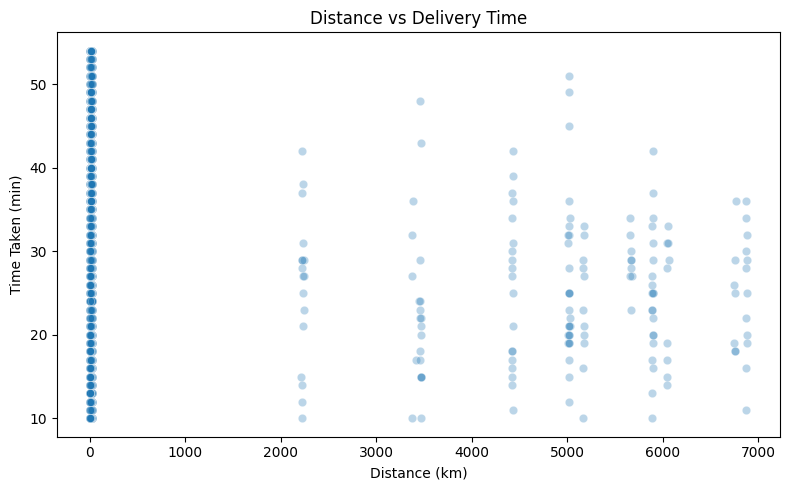

In [73]:
# Distance vs delivery time

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="Time_taken (min)",
    alpha=0.3
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [74]:
# Checking how many engineered distances are extreme

print("Distance > 50 km:",
      (df["distance_km"] > 50).sum())

print("Distance > 100 km:",
      (df["distance_km"] > 100).sum())

print("Distance > 500 km:",
      (df["distance_km"] > 500).sum())

print("Distance > 1000 km:",
      (df["distance_km"] > 1000).sum())

Distance > 50 km: 153
Distance > 100 km: 153
Distance > 500 km: 153
Distance > 1000 km: 153


In [75]:
# Inspecting the most extreme distances

display(
    df.nlargest(15, "distance_km")[
        [
            "Restaurant_latitude",
            "Restaurant_longitude",
            "Delivery_location_latitude",
            "Delivery_location_longitude",
            "distance_km",
            "Time_taken (min)"
        ]
    ]
)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance_km,Time_taken (min)
3768,-30.902872,75.826808,31.012872,75.936808,6884.726399,25
2687,-30.895817,75.813112,31.005817,75.923112,6883.157441,19
2437,-30.902872,75.826808,30.972872,75.896808,6880.272782,20
24199,-30.895817,75.813112,30.965817,75.883112,6878.703822,32
21661,-30.899584,75.809346,30.959584,75.869346,6878.428563,29
17665,-30.885814,75.786976,30.965814,75.866976,6877.592421,36
24931,-30.899584,75.809346,30.949584,75.859346,6877.315724,16
23189,-30.873988,75.842739,30.963988,75.932739,6876.075767,34
9185,-30.885915,75.788259,30.945915,75.848259,6875.388718,30
7666,-30.899584,75.809346,30.929584,75.839346,6875.090529,22


Start Point (-30.902872, 75.826808): Open ocean water, roughly 1,900 kilometres west of Geraldton, **Australia**.

End Point (31.012872, 75.936808): Just northeast of Ludhiana city centre, near the Sutlej River area in **Punjab**, India.

i.e not posible

In [76]:
# Checking all negative restaurant latitudes

negative_lat = df[df["Restaurant_latitude"] < 0]

print("Negative restaurant latitudes:", len(negative_lat))

display(
    negative_lat[
        [
            "Restaurant_latitude",
            "Restaurant_longitude",
            "Delivery_location_latitude",
            "Delivery_location_longitude",
            "distance_km"
        ]
    ].head(20)
)

Negative restaurant latitudes: 153


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance_km
80,-27.163303,78.057044,27.233303,78.127044,6048.631240
259,-27.165108,78.015053,27.225108,78.075053,6047.919478
1013,-15.546594,73.760431,15.606594,73.820431,3464.082720
1644,-23.230791,77.437020,23.250791,77.457020,5168.516553
1824,-22.539129,88.365507,22.549129,88.375507,5013.585658
1940,-15.157944,73.950889,15.197944,73.990889,3375.423601
1976,-9.959778,76.296106,9.969778,76.306106,2216.065794
2036,-15.513150,73.783460,15.563150,73.833460,3455.531261
2122,-15.576683,73.755750,15.646683,73.825750,3471.888400
2437,-30.902872,75.826808,30.972872,75.896808,6880.272782


**Negative Restaurant Latitudes**

While validating the geographical coordinates, I found some negative values in `Restaurant_latitude`.

Since the dataset represents locations in India, restaurant latitudes should fall within India's northern latitude range. The negative values were therefore treated as a sign error rather than valid southern-hemisphere locations.

**Solution:** Convert only the negative restaurant latitudes to their absolute values.

In [77]:
# Correct only negative restaurant latitudes

df.loc[
    df["Restaurant_latitude"] < 0,
    "Restaurant_latitude"
] = df.loc[
    df["Restaurant_latitude"] < 0,
    "Restaurant_latitude"
].abs()

In [78]:
# Validate the correction

print("Negative restaurant latitudes:",
      (df["Restaurant_latitude"] < 0).sum())

print("\nMinimum restaurant latitude:",
      df["Restaurant_latitude"].min())

Negative restaurant latitudes: 0

Minimum restaurant latitude: 0.0


In [79]:
# Recalculate distance using corrected restaurant latitude

df["distance_km"] = df.apply(
    lambda row: haversine_distance(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ),
    axis=1
)

In [80]:
# Validate corrected distance feature

print(df["distance_km"].describe())

print("\nDistance > 50 km:",
      (df["distance_km"] > 50).sum())

print("Distance > 100 km:",
      (df["distance_km"] > 100).sum())

print("Distance > 1000 km:",
      (df["distance_km"] > 1000).sum())

count    42508.000000
mean         9.758236
std          5.607530
min          1.465067
25%          4.663439
50%          9.220419
75%         13.681602
max         20.969489
Name: distance_km, dtype: float64

Distance > 50 km: 0
Distance > 100 km: 0
Distance > 1000 km: 0


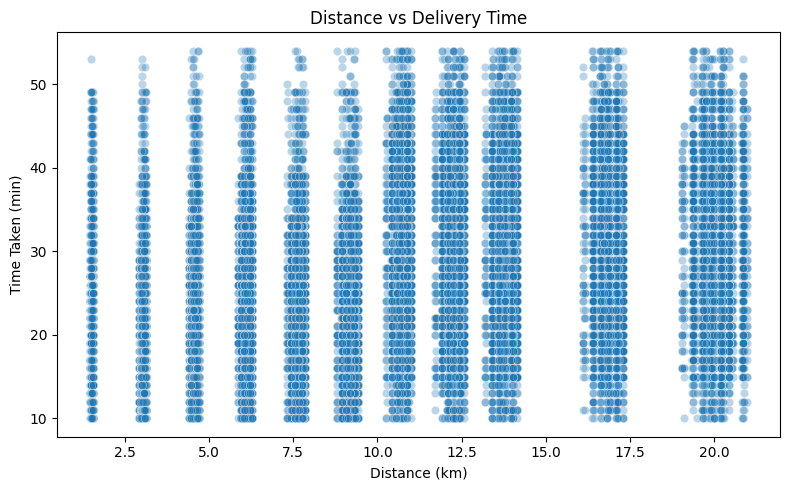

In [81]:
# Distance vs delivery time

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="Time_taken (min)",
    alpha=0.3
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Time Taken (min)")

plt.tight_layout()
plt.show()

In [82]:
print(
    "Distance vs Time correlation:",
    df["distance_km"].corr(df["Time_taken (min)"])
)

Distance vs Time correlation: 0.3230060125498305


In [83]:
df.rename(
    columns={"Time_taken (min)": "Time_taken_min"},
    inplace=True
)

In [84]:
df

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_min,Order_Hour,Picked_Hour,Day_of_Week,distance_km
0,36.0,4.2,30.327968,78.046106,30.397968,78.116106,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,21.0,22,Saturday,10.280582
1,21.0,4.7,10.003064,76.307589,10.043064,76.347589,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,14.0,15,Sunday,6.242319
2,23.0,4.7,18.562450,73.916619,18.652450,74.006619,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,17.0,17,Friday,13.787860
3,34.0,4.3,30.899584,75.809346,30.919584,75.829346,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,9.0,9,Sunday,2.930258
4,24.0,4.7,26.463504,80.372929,26.593504,80.502929,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.0,20,Monday,19.396618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42503,30.0,4.8,26.902328,75.794257,26.912328,75.804257,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,11.0,11,Thursday,1.489846
42504,21.0,4.6,0.000000,0.000000,0.070000,0.070000,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36,19.0,20,Wednesday,11.007735
42505,30.0,4.9,13.022394,80.242439,13.052394,80.272439,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,23.0,0,Friday,4.657195
42506,20.0,4.7,11.001753,76.986241,11.041753,77.026241,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,13.0,13,Monday,6.232393


## Data preprocessing

In [85]:
# Separate features and target

X = df.drop(columns=["Time_taken_min"])
y = df["Time_taken_min"]

In [86]:
# Common regression models

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

In [87]:
# Spliting the data for training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (34006, 18)
X_test : (8502, 18)
y_train: (34006,)
y_test : (8502,)


**Why use ColumnTransformer?**

Our dataset contains both numerical and categorical features, and they require different preprocessing.

- Numerical features need scaling using `StandardScaler`.
- Categorical features need to be converted into numerical values using `OneHotEncoder`.

Instead of modifying the main DataFrame manually, `ColumnTransformer` allows us to apply the correct preprocessing to each group of columns while keeping the original dataset unchanged.

This is especially useful when working with train-test splits because the preprocessing can be fitted only on the training data, **helping prevent data leakage**.

In [89]:
#              X_train
#                 ↓
#        ┌────────┴────────┐
#        ↓                 ↓
#  Numerical           Categorical
#        ↓                 ↓
# StandardScaler    OneHotEncoder
#        └────────┬────────┘
#                 ↓
#         Processed X_train
#                 ↓
#           LinearRegression

In [90]:
# Identify numerical and categorical features

num_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(num_features)

print("\nCategorical features:")
print(cat_features)

Numerical features:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries', 'Order_Hour', 'Picked_Hour', 'distance_km']

Categorical features:
['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Day_of_Week']


**Why use a Pipeline?**

We could manually scale and encode `X_train` and `X_test`, but that creates more steps and increases the chance of accidentally fitting preprocessing on the test data.

A Pipeline combines preprocessing and model training into one workflow.

During training:

X_train → preprocessing → Linear Regression

During prediction:

X_test → same preprocessing → Linear Regression

The preprocessing is fitted using only the training data, which helps prevent data leakage and ensures that new data is processed consistently.

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [92]:
# Preprocessing for numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

**Baseline Linear Regression**

In [93]:
# Baseline Linear Regression
from sklearn.pipeline import Pipeline
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [94]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'Restaurant_latitude',
                                                   'Restaurant_longitude',
                                                   'Delivery_location_latitude',
                                                   'Delivery_location_longitude',
                                                   'Vehicle_condition',
                                                   'multiple_deliveries',
                                                   'Order_Hour', 'Picked_Hour',
                                                   'distance_km']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Weather_conditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City',
                                                   'Day_of_Week'])])),
                ('model', LinearRegression())])

In [95]:
y_pred = linear_model.predict(X_test)

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [97]:
# Evaluate baseline model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Baseline")
print("--------------------------")
print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R²   : {r2:.3f}")

Linear Regression Baseline
--------------------------
MAE  : 4.70 minutes
RMSE : 5.92 minutes
R²   : 0.602


In [98]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

display(comparison.head(10))

,Actual,Predicted
10883,17,21.582331
5771,26,30.074691
24960,41,31.026790
13374,35,39.114934
10859,42,39.845737
5878,34,28.859427
29027,16,23.806061
41633,22,23.754213
38236,35,23.462714
15253,48,44.755889


In [99]:
print("Actual mean    :", y_test.mean())
print("Predicted mean :", y_pred.mean())

Actual mean    : 26.524582451187957
Predicted mean : 26.470397239201933


**Baseline DecisionTree Regression**

In [100]:
from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42
        ))
    ]
)

In [101]:
# train
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'Restaurant_latitude',
                                                   'Restaurant_longitude',
                                                   'Delivery_location_latitude',
                                                   'Delivery_location_longitude',
                                                   'Vehicle_condition',
                                                   'multiple_deliveries',
                                                   'Order_Hour', 'Picked_Hour',
                                                   'distance_km']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Weather_conditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City',
                                                   'Day_of_Week'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [102]:
# Predict:
tree_pred = tree_model.predict(X_test)

In [103]:
# evaluate:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree")
print("--------------------------")
print(f"MAE  : {tree_mae:.2f} minutes")
print(f"RMSE : {tree_rmse:.2f} minutes")
print(f"R²   : {tree_r2:.3f}")

Decision Tree
--------------------------
MAE  : 4.05 minutes
RMSE : 5.26 minutes
R²   : 0.685


**Baseline Random Forest**

In [104]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("--------------------------")
print(f"MAE  : {rf_mae:.2f} minutes")
print(f"RMSE : {rf_rmse:.2f} minutes")
print(f"R²   : {rf_r2:.3f}")

Random Forest
--------------------------
MAE  : 3.09 minutes
RMSE : 3.85 minutes
R²   : 0.832


*The delivery-time relationship is strongly nonlinear and involves interactions between features.*

In [105]:
rf_train_pred = rf_model.predict(X_train)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_pred)

print("Random Forest Train R²:", round(rf_train_r2, 3))
print("Random Forest Test R² :", round(rf_test_r2, 3))

Random Forest Train R²: 0.976
Random Forest Test R² : 0.832


In [106]:
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Train MAE:", round(rf_train_mae, 2))
print("Random Forest Test MAE :", round(rf_test_mae, 2))

Random Forest Train MAE: 1.14
Random Forest Test MAE : 3.09


**Random Forest Overfitting Check**

The Random Forest performs much better on the training data than on the test data:

- Train R²: 0.976
- Test R²: 0.832
- Train MAE: 1.14 minutes
- Test MAE: 3.09 minutes

This indicates some overfitting. The model is learning the training data very closely, but it still generalizes reasonably well to unseen data.

We will tune the Random Forest hyperparameters to control tree complexity and determine whether test performance can be improved while reducing the train-test gap.

**Baseline Gradient Boosting Regressor**

In [107]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

In [108]:
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'Restaurant_latitude',
                                                   'Restaurant_longitude',
                                                   'Delivery_location_latitude',
                                                   'Delivery_location_longitude',
                                                   'Vehicle_condition',
                                                   'multiple_deliveries',
                                                   'Order_Hour', 'Picked_Hour',
                                                   'distance_km']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Weather_conditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City',
                                                   'Day_of_Week'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [109]:
gb_pred = gb_model.predict(X_test)

In [110]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("--------------------------")
print(f"MAE  : {gb_mae:.2f} minutes")
print(f"RMSE : {gb_rmse:.2f} minutes")
print(f"R²   : {gb_r2:.3f}")

Gradient Boosting
--------------------------
MAE  : 3.50 minutes
RMSE : 4.36 minutes
R²   : 0.785


**Baseline XGBoost Regressor**

In [111]:
from xgboost import XGBRegressor

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [112]:
# Train:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'Restaurant_latitude',
                                                   'Restaurant_longitude',
                                                   'Delivery_location_latitude',
                                                   'Delivery_location_longitude',
                                                   'Vehicle_condition',
                                                   'multiple_deliveries',
                                                   'Order_Hour', 'Picked_Hour',
                                                   'distance_km']),
                                                 ('cat',
                                                  OneHotEncoder(han...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [113]:
# Predict:
xgb_pred = xgb_model.predict(X_test)

In [114]:
# Evaluate:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("--------------------------")
print(f"MAE  : {xgb_mae:.2f} minutes")
print(f"RMSE : {xgb_rmse:.2f} minutes")
print(f"R²   : {xgb_r2:.3f}")

XGBoost
--------------------------
MAE  : 3.14 minutes
RMSE : 3.91 minutes
R²   : 0.827


In [115]:
'''
Linear Regression
R² = 0.602
       ↓
"Linear relationships aren't enough"

Decision Tree
R² = 0.685
       ↓
"Nonlinear relationships help"

Gradient Boosting
R² = 0.785
       ↓
"Sequential boosting captures more"

Random Forest
R² = 0.832
       ↓
"Ensembling trees works very well"

XGBoost
R² = 0.827
       ↓
"Strong model, but defaults aren't quite enough"
'''

'\nLinear Regression\nR² = 0.602\n       ↓\n"Linear relationships aren\'t enough"\n\nDecision Tree\nR² = 0.685\n       ↓\n"Nonlinear relationships help"\n\nGradient Boosting\nR² = 0.785\n       ↓\n"Sequential boosting captures more"\n\nRandom Forest\nR² = 0.832\n       ↓\n"Ensembling trees works very well"\n\nXGBoost\nR² = 0.827\n       ↓\n"Strong model, but defaults aren\'t quite enough"\n'

In [116]:
# now we do cv and hyperparameter tuning on Random Forest and XGBoost

**Tuned Random Forest**

In [117]:
from sklearn.model_selection import RandomizedSearchCV

In [118]:
# Hyperparameter search space for Random Forest

param_dist = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [10, 15, 20, 25, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.7, 1.0]
}

In [119]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [120]:
rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Delivery_person_Age',
                                                                                'Delivery_person_Ratings',
                                                                                'Restaurant_latitude',
                                                                                'Restaurant_longitude',
                                                                                'Delivery_location_latitude',
                                                                                'Delivery_location_longitude',
                                                                                'Vehicle_condition',
                                                                                'multiple_deliveries',
                                                                                'Order_Hour',
                                                                                'Picked_Hour',
                                                                                'dista...
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 15, 20, 25,
                                                             None],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.7, 1.0],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                400]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [121]:
print("Best parameters:")
print(rf_random_search.best_params_)

print("\nBest CV MAE:")
print(-rf_random_search.best_score_)

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': 20}

Best CV MAE:
3.049682214943624


In [122]:
'''
Baseline:
n_estimators = 100
max_depth = None
min_samples_split = 2
min_samples_leaf = 1
max_features = 1.0

Tuned:
n_estimators = 300
max_depth = 20
min_samples_split = 5
min_samples_leaf = 4
max_features = 0.7
'''

'\nBaseline:\nn_estimators = 100\nmax_depth = None\nmin_samples_split = 2\nmin_samples_leaf = 1\nmax_features = 1.0\n\nTuned:\nn_estimators = 300\nmax_depth = 20\nmin_samples_split = 5\nmin_samples_leaf = 4\nmax_features = 0.7\n'

In [123]:
best_rf_model = rf_random_search.best_estimator_

In [124]:
best_rf_pred = best_rf_model.predict(X_test)

In [125]:
# Evaluate tuned Random Forest

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest")
print("--------------------------")
print(f"MAE  : {best_rf_mae:.2f} minutes")
print(f"RMSE : {best_rf_rmse:.2f} minutes")
print(f"R²   : {best_rf_r2:.3f}")

Tuned Random Forest
--------------------------
MAE  : 3.04 minutes
RMSE : 3.77 minutes
R²   : 0.838


In [126]:
# Check overfitting after tuning

best_rf_train_pred = best_rf_model.predict(X_train)

best_rf_train_r2 = r2_score(y_train, best_rf_train_pred)
best_rf_train_mae = mean_absolute_error(y_train, best_rf_train_pred)

print("Tuned RF Train MAE:", round(best_rf_train_mae, 2))
print("Tuned RF Test MAE :", round(best_rf_mae, 2))

print("\nTuned RF Train R²:", round(best_rf_train_r2, 3))
print("Tuned RF Test R² :", round(best_rf_r2, 3))

Tuned RF Train MAE: 1.98
Tuned RF Test MAE : 3.04

Tuned RF Train R²: 0.93
Tuned RF Test R² : 0.838


**Tunned XGBoost**

In [127]:
# XGBoost tuning

xgb_param_dist = {
    "model__n_estimators": [500, 600, 700],
    "model__max_depth": [6, 7, 8],
    "model__learning_rate": [0.02, 0.03, 0.05],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [3, 5, 7],
    "model__reg_lambda": [1, 2, 5]
}

In [128]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=15,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=123,
    n_jobs=-1,
    verbose=1
)

In [129]:
xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Delivery_person_Age',
                                                                                'Delivery_person_Ratings',
                                                                                'Restaurant_latitude',
                                                                                'Restaurant_longitude',
                                                                                'Delivery_location_latitude',
                                                                                'Delivery_location_longitude',
                                                                                'Vehicle_condition',
                                                                                'multiple_deliveries',
                                                                                'Order_Hour',
                                                                                'Picked_Hour',
                                                                                'dista...
                                                           num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 0.9,
                                                                    1.0],
                                        'model__learning_rate': [0.02, 0.03,
                                                                 0.05],
                                        'model__max_depth': [6, 7, 8],
                                        'model__min_child_weight': [3, 5, 7],
                                        'model__n_estimators': [500, 600, 700],
                                        'model__reg_lambda': [1, 2, 5],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=123, scoring='neg_mean_absolute_error',
                   verbose=1)

In [130]:
print("Best parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV MAE:")
print(-xgb_random_search.best_score_)

Best parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 1, 'model__n_estimators': 500, 'model__min_child_weight': 7, 'model__max_depth': 7, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}

Best CV MAE:
3.0208120822906492


In [131]:
# Evaluate Tuned XGBoost

best_xgb = xgb_random_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("Tuned XGBoost")
print("--------------------------")
print(f"MAE  : {xgb_mae:.2f} minutes")
print(f"RMSE : {xgb_rmse:.2f} minutes")
print(f"R²   : {xgb_r2:.3f}")

Tuned XGBoost
--------------------------
MAE  : 3.01 minutes
RMSE : 3.76 minutes
R²   : 0.840


In [132]:
# Check for overfitting

xgb_train_pred = best_xgb.predict(X_train)

train_mae = mean_absolute_error(y_train, xgb_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
train_r2 = r2_score(y_train, xgb_train_pred)

print("Tuned XGBoost - Overfitting Check")
print("-----------------------------------------")
print(f"Train MAE  : {train_mae:.2f} minutes")
print(f"Test MAE   : {xgb_mae:.2f} minutes")
print(f"Train RMSE : {train_rmse:.2f} minutes")
print(f"Test RMSE  : {xgb_rmse:.2f} minutes")
print(f"Train R²   : {train_r2:.3f}")
print(f"Test R²    : {xgb_r2:.3f}")

Tuned XGBoost - Overfitting Check
-----------------------------------------
Train MAE  : 2.71 minutes
Test MAE   : 3.01 minutes
Train RMSE : 3.38 minutes
Test RMSE  : 3.76 minutes
Train R²   : 0.869
Test R²    : 0.840


In [133]:
best_xgb_model = xgb_random_search.best_estimator_

In [136]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "MAE": [
        4.70,
        4.05,
        3.09,
        3.50,
        3.14,
        3.04,
        3.01
    ],
    "RMSE": [
        5.92,
        5.26,
        3.85,
        4.36,
        3.91,
        3.77,
        3.76
    ],
    "R2": [
        0.602,
        0.685,
        0.832,
        0.785,
        0.827,
        0.838,
        0.840
    ]
})

final_results.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
6,Tuned XGBoost,3.01,3.76,0.840
5,Tuned Random Forest,3.04,3.77,0.838
2,Random Forest,3.09,3.85,0.832
4,XGBoost,3.14,3.91,0.827
3,Gradient Boosting,3.50,4.36,0.785
1,Decision Tree,4.05,5.26,0.685
0,Linear Regression,4.70,5.92,0.602


### Final Model Selection

Tuned XGBoost achieved the best performance on the held-out test set, with an MAE of **3.01** minutes and an R² of **0.840**.

The train-test performance gap is relatively small compared with the baseline Random Forest, suggesting that the tuned XGBoost model generalizes reasonably well.

Therefore, tuned XGBoost is selected as the primary ETA prediction model.

In [137]:
# Freeze the final ETA model

final_eta_model = best_xgb_model

In [138]:
print("Final ETA Model:")
print(final_eta_model)

Final ETA Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'Restaurant_latitude',
                                                   'Restaurant_longitude',
                                                   'Delivery_location_latitude',
                                                   'Delivery_location_longitude',
                                                   'Vehicle_condition',
                                                   'multiple_deliveries',
                                                   'Order_Hour', 'Picked_Hour',
                                                   'distance_km']),
                                                 ('cat',
                                                  OneHotEnco

In [139]:
final_eta_pred = final_eta_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_eta_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_eta_pred))
final_r2 = r2_score(y_test, final_eta_pred)

print("Final ETA Model Performance")
print("----------------------------")
print(f"MAE  : {final_mae:.2f} minutes")
print(f"RMSE : {final_rmse:.2f} minutes")
print(f"R²   : {final_r2:.3f}")

Final ETA Model Performance
----------------------------
MAE  : 3.01 minutes
RMSE : 3.76 minutes
R²   : 0.840


## Feature Importance

In [140]:
# Extract the trained XGBoost model

xgb_final = final_eta_model.named_steps["model"]

In [141]:
# Get feature names after preprocessing

feature_names = final_eta_model.named_steps["preprocessor"].get_feature_names_out()

In [142]:
print("Number of features:", len(feature_names))

Number of features: 40


In [143]:
importance = xgb_final.feature_importances_

In [144]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
19,cat__Road_traffic_density_Low,0.224230
7,num__multiple_deliveries,0.107210
15,cat__Weather_conditions_Sunny,0.089480
1,num__Delivery_person_Ratings,0.088039
28,cat__Festival_No,0.073101
11,cat__Weather_conditions_Cloudy,0.067274
12,cat__Weather_conditions_Fog,0.065480
18,cat__Road_traffic_density_Jam,0.054875
6,num__Vehicle_condition,0.043941
10,num__distance_km,0.029094


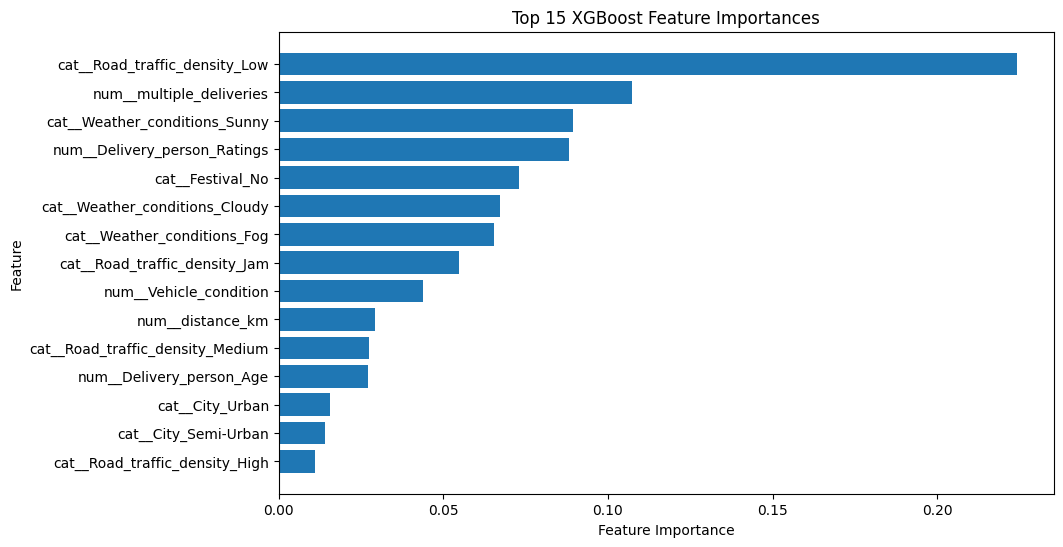

In [145]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

**Feature Importance**

XGBoost feature importance shows which encoded features were most frequently/usefully used by the model when making predictions.

Road traffic density, multiple deliveries, weather conditions, delivery-person ratings, and festival status appear among the most important individual features.

However, categorical variables have been one-hot encoded, meaning each category appears as a separate feature. Therefore, the importance of individual categories should not be interpreted as the overall importance of the original categorical variable.

Feature importance also does not show whether a feature increases or decreases the predicted ETA. SHAP analysis will be used next to understand both the magnitude and direction of individual feature contributions.

## SHAP(SHapley Additive exPlanations)

SHAP (SHapley Additive exPlanations) is used to explain how machine learning models make predictions by showing how much each input feature contributes to a final result

for eg:
- Why did this particular order get a 31-minute ETA?
- Which features pushed the prediction UP?
- Which features pushed it DOWN?
- How much did traffic contribute?
- How much did distance contribute?
- Does more distance consistently increase predicted ETA?

In [146]:
import shap

In [147]:
# Create SHAP explainer

xgb_model = final_eta_model.named_steps["model"]

explainer = shap.TreeExplainer(xgb_model)

In [148]:
X_test_transformed = final_eta_model.named_steps["preprocessor"].transform(X_test)

In [149]:
shap_values = explainer.shap_values(X_test_transformed)

In [150]:
print("X_test shape:", X_test.shape)
print("Transformed X_test shape:", X_test_transformed.shape)
print("SHAP values shape:", shap_values.shape)

X_test shape: (8502, 18)
Transformed X_test shape: (8502, 40)
SHAP values shape: (8502, 40)


In [151]:
feature_names = final_eta_model.named_steps[
    "preprocessor"
].get_feature_names_out()

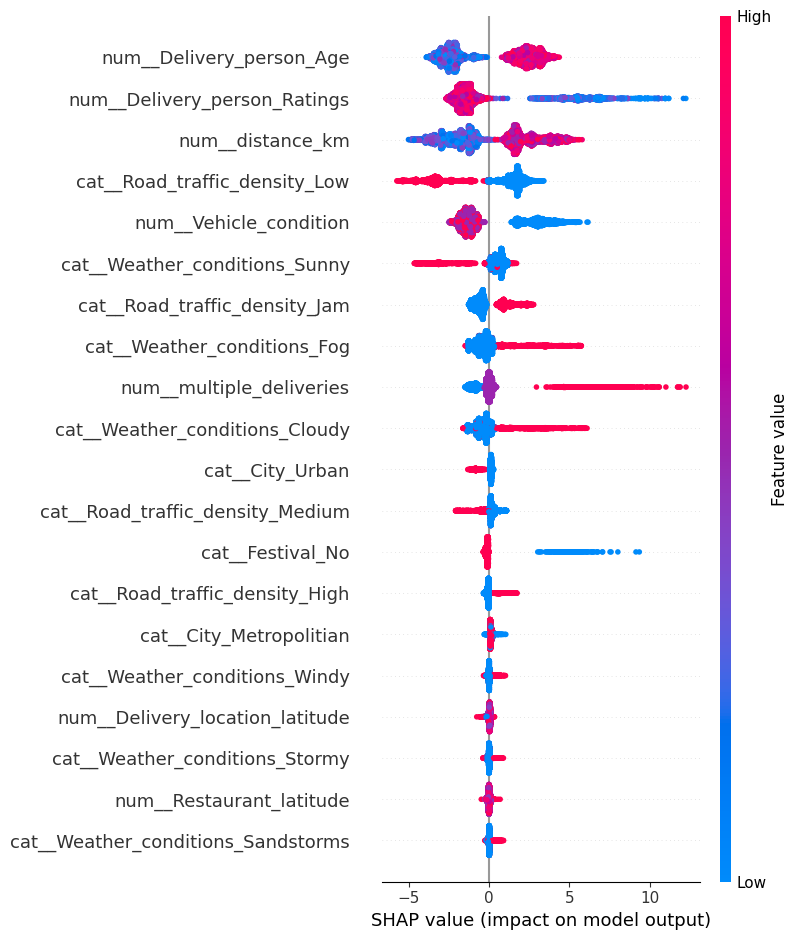

In [152]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

### Shap Explaination

In [154]:
# Select one order from the test set

sample_index = 0

X_sample = X_test.iloc[[sample_index]]
y_sample = y_test.iloc[sample_index]

print("Actual ETA:", y_sample)

Actual ETA: 17


In [156]:
# Predict ETA for the selected order

sample_pred = final_eta_model.predict(X_sample)[0]

print("Predicted ETA:", sample_pred)

Predicted ETA: 15.500315


In [157]:
# Transform the selected order for SHAP

X_sample_transformed = final_eta_model.named_steps[
    "preprocessor"
].transform(X_sample)

sample_shap_values = explainer.shap_values(
    X_sample_transformed
)

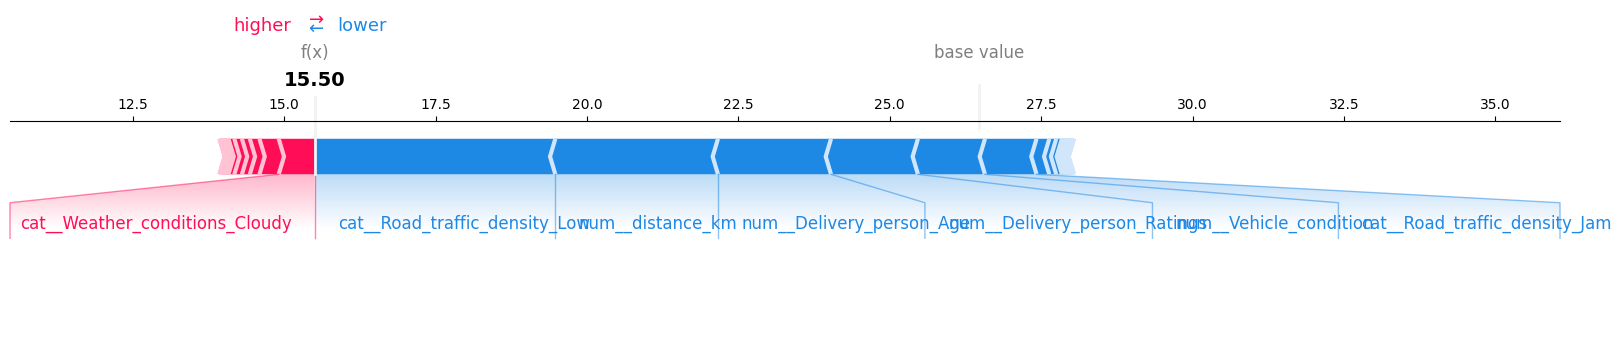

In [158]:
# Explain the individual prediction

shap.force_plot(
    explainer.expected_value,
    sample_shap_values[0],
    feature_names=feature_names,
    matplotlib=True
)

plt.show()

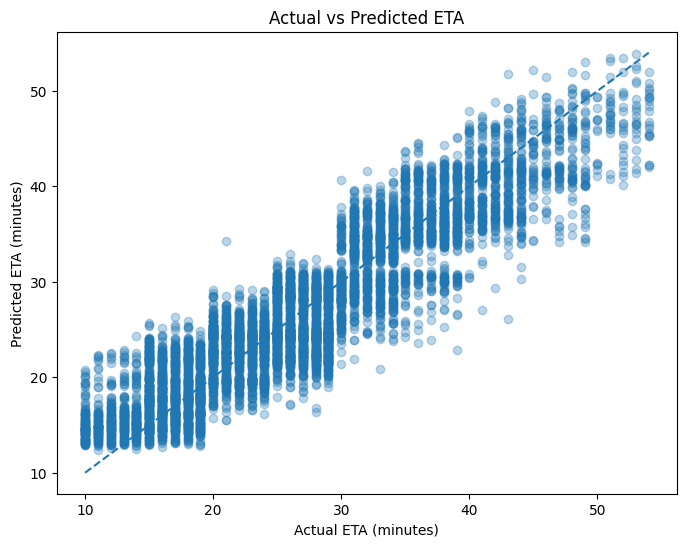

In [159]:
# Actual vs Predicted ETA

plt.figure(figsize=(8, 6))

plt.scatter(y_test, final_eta_pred, alpha=0.3)

plt.xlabel("Actual ETA (minutes)")
plt.ylabel("Predicted ETA (minutes)")
plt.title("Actual vs Predicted ETA")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

A strong diagonal pattern

As actual delivery time increases, the model's predicted delivery time also increases.

In [160]:
# Calculate prediction errors

residuals = y_test - final_eta_pred

print(residuals.describe())

count    8502.000000
mean        0.046308
std         3.756876
min       -13.247452
25%        -2.643309
50%        -0.123057
75%         2.593988
max        16.905680
Name: Time_taken_min, dtype: float64


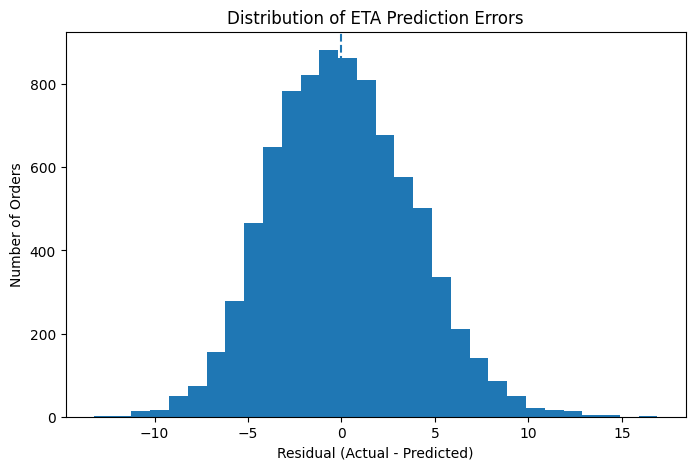

In [161]:
# Residual Distribution

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.axvline(0, linestyle="--")

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Orders")
plt.title("Distribution of ETA Prediction Errors")

plt.show()

# nearest_store_df

In [162]:
base_df = df.copy()

print("Shape:", base_df.shape)
print("\nColumns:")
print(base_df.columns.tolist())

Shape: (42508, 19)

Columns:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken_min', 'Order_Hour', 'Picked_Hour', 'Day_of_Week', 'distance_km']


In [205]:
base_df.head(20)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken_min,Order_Hour,Picked_Hour,Day_of_Week,distance_km
0,36.0,4.2,30.327968,78.046106,30.397968,78.116106,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,21.0,22,Saturday,10.280582
1,21.0,4.7,10.003064,76.307589,10.043064,76.347589,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,14.0,15,Sunday,6.242319
2,23.0,4.7,18.562450,73.916619,18.652450,74.006619,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,17.0,17,Friday,13.787860
3,34.0,4.3,30.899584,75.809346,30.919584,75.829346,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,9.0,9,Sunday,2.930258
4,24.0,4.7,26.463504,80.372929,26.593504,80.502929,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.0,20,Monday,19.396618
5,29.0,4.5,19.176269,72.836721,19.266269,72.926721,Sandstorms,Jam,2,Buffet,electric_scooter,1.0,No,Metropolitian,20,20.0,20,Saturday,13.763977
6,35.0,4.0,12.311072,76.654878,12.351072,76.694878,Windy,High,1,Meal,scooter,1.0,No,Metropolitian,33,14.0,15,Tuesday,6.218001
7,33.0,4.2,18.592718,73.773572,18.702718,73.883572,Sandstorms,Jam,2,Snack,motorcycle,1.0,No,Metropolitian,40,20.0,20,Wednesday,16.849940
8,34.0,4.9,17.426228,78.407495,17.496228,78.477495,Cloudy,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,41,20.0,20,Sunday,10.757109
9,21.0,4.7,22.552672,88.352885,22.582672,88.382885,Windy,Jam,0,Meal,motorcycle,1.0,No,Urban,15,21.0,21,Tuesday,4.540574


In [163]:
# Numerical columns
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings"
]

for col in numeric_cols:
    if col in base_df.columns:
        base_df[col] = base_df[col].fillna(base_df[col].median())


# Categorical columns
categorical_cols = [
    "City",
    "multiple_deliveries",
    "Weather_conditions",
    "Road_traffic_density",
    "Festival"
]

for col in categorical_cols:
    if col in base_df.columns:
        base_df[col] = base_df[col].fillna(base_df[col].mode()[0])


print("Remaining missing values:")
print(base_df.isnull().sum()[base_df.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


In [164]:
base_df[
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].head()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
0,30.327968,78.046106,30.397968,78.116106
1,10.003064,76.307589,10.043064,76.347589
2,18.562450,73.916619,18.652450,74.006619
3,30.899584,75.809346,30.919584,75.829346
4,26.463504,80.372929,26.593504,80.502929


In [165]:
zepto_stores= pd.read_csv('/kaggle/input/datasets/afreeenarshi/zepto-darkstore-dataset/zepto-darkstores.csv')
blinkit_stores= pd.read_csv('/kaggle/input/datasets/afreeenarshi/blinkit-darkstore-dataset/blinkit-darkstores.csv')
instamart_stores= pd.read_csv('/kaggle/input/datasets/afreeenarshi/instamart-darkstore-dataset/swiggy-darkstores.csv')

In [166]:
print("BLINKIT")
print(blinkit_stores.shape)
print(blinkit_stores.columns.tolist())

print("\nZEPTO")
print(zepto_stores.shape)
print(zepto_stores.columns.tolist())

print("\nINSTAMART")
print(instamart_stores.shape)
print(instamart_stores.columns.tolist())

BLINKIT
(1954, 4)
['id', 'accuracy', 'lat', 'lng']

ZEPTO
(1089, 6)
['id', 'name', 'lat', 'lng', 'city', 'state']

INSTAMART
(1038, 4)
['id', 'locality', 'lat', 'lng']


In [167]:
from sklearn.neighbors import BallTree

In [168]:
# Store datasets
store_datasets = {
    "Blinkit": blinkit_stores,
    "Zepto": zepto_stores,
    "Instamart": instamart_stores
}

# Make sure lat/lng are numeric
for platform, stores in store_datasets.items():
    stores["lat"] = pd.to_numeric(stores["lat"], errors="coerce")
    stores["lng"] = pd.to_numeric(stores["lng"], errors="coerce")

    # Remove invalid/missing coordinates
    stores.dropna(subset=["lat", "lng"], inplace=True)

    # Reset index
    stores.reset_index(drop=True, inplace=True)

print("Blinkit:", blinkit_stores.shape)
print("Zepto:", zepto_stores.shape)
print("Instamart:", instamart_stores.shape)

Blinkit: (1954, 4)
Zepto: (1089, 6)
Instamart: (1038, 4)


In [169]:
# Building a BallTree for each platform
store_trees = {}

for platform, stores in store_datasets.items():

    # BallTree with haversine requires radians
    coordinates = np.radians(
        stores[["lat", "lng"]].values
    )

    tree = BallTree(
        coordinates,
        metric="haversine"
    )

    store_trees[platform] = tree

In [170]:
# Creating the customer coordinates
customer_coordinates = base_df[
    [
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].copy()

customer_coordinates.columns = ["customer_lat", "customer_lng"]

customer_coordinates["customer_lat"] = pd.to_numeric(
    customer_coordinates["customer_lat"],
    errors="coerce"
)

customer_coordinates["customer_lng"] = pd.to_numeric(
    customer_coordinates["customer_lng"],
    errors="coerce"
)

In [171]:
# Finding stores within 4 km
RADIUS_KM = 4
EARTH_RADIUS_KM = 6371.0088

candidate_results = []

for customer_idx, customer in customer_coordinates.iterrows():

    if pd.isna(customer["customer_lat"]) or pd.isna(customer["customer_lng"]):
        continue

    customer_point = np.radians(
        [[customer["customer_lat"], customer["customer_lng"]]]
    )

    for platform, tree in store_trees.items():

        # Find every store within 4 km function 
        indices, distances = tree.query_radius(
            customer_point,
            r=RADIUS_KM / EARTH_RADIUS_KM,
            return_distance=True,
            sort_results=True
        )

        store_indices = indices[0]
        store_distances = distances[0]

        stores = store_datasets[platform]

        for store_idx, distance_rad in zip(
            store_indices,
            store_distances
        ):

            candidate_results.append({
                "customer_idx": customer_idx,
                "platform": platform,
                "store_id": stores.iloc[store_idx]["id"],
                "customer_lat": customer["customer_lat"],
                "customer_lng": customer["customer_lng"],
                "store_lat": stores.iloc[store_idx]["lat"],
                "store_lng": stores.iloc[store_idx]["lng"],
                "distance_km": distance_rad * EARTH_RADIUS_KM
            })

In [172]:
candidate_df = pd.DataFrame(candidate_results)

In [204]:
candidate_df.head()

,customer_idx,platform,store_id,customer_lat,customer_lng,store_lat,store_lng,distance_km
0,0,Blinkit,36640.0,30.397968,78.116106,30.376907,78.109008,2.438828
1,0,Zepto,9b74fd73-1753-4b1c-a6df-6b8d01bd168c,30.397968,78.116106,30.372331,78.098837,3.296999
2,1,Blinkit,36590.0,10.043064,76.347589,10.016227,76.362413,3.397034
3,1,Blinkit,35852.0,10.043064,76.347589,10.008747,76.342281,3.859871
4,1,Zepto,1c6c1528-3f93-42f0-8640-66ba46e9dace,10.043064,76.347589,10.037460,76.341296,0.929015


In [174]:
candidate_df.shape

(287065, 8)

In [175]:
candidate_df.groupby("platform").size()

platform
Blinkit      115218
Instamart     77156
Zepto         94691
dtype: int64

In [176]:
candidate_df.groupby("platform")["distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
Blinkit,115218.0,2.653956,0.934704,0.046055,1.999212,2.795576,3.432888,3.999477
Instamart,77156.0,2.639775,0.944240,0.030044,1.953304,2.781031,3.444202,3.999873
Zepto,94691.0,2.644291,0.945017,0.044345,1.970051,2.791914,3.440274,3.999866


In [177]:
# unique customers have at least one store within 4 km for each platform
coverage = (
    candidate_df
    .groupby("platform")["customer_idx"]
    .nunique()
)

coverage

platform
Blinkit      26228
Instamart    23258
Zepto        21443
Name: customer_idx, dtype: int64

In [178]:
# Finding the nearest store per platform
nearest_store_df = (
    candidate_df
    .sort_values("distance_km")
    .groupby(
        ["customer_idx", "platform"],
        as_index=False
    )
    .first()
)

In [180]:
nearest_store_df.head(10)

,customer_idx,platform,store_id,customer_lat,customer_lng,store_lat,store_lng,distance_km
0,0,Blinkit,36640.0,30.397968,78.116106,30.376907,78.109008,2.438828
1,0,Zepto,9b74fd73-1753-4b1c-a6df-6b8d01bd168c,30.397968,78.116106,30.372331,78.098837,3.296999
2,1,Blinkit,36590.0,10.043064,76.347589,10.016227,76.362413,3.397034
3,1,Instamart,1319695,10.043064,76.347589,10.028450,76.370564,2.994825
4,1,Zepto,1c6c1528-3f93-42f0-8640-66ba46e9dace,10.043064,76.347589,10.037460,76.341296,0.929015
5,3,Blinkit,43549.0,30.919584,75.829346,30.926243,75.834557,0.891815
6,3,Instamart,1397034,30.919584,75.829346,30.916722,75.823333,0.655974
7,3,Zepto,9ac5f009-7623-4d1f-9b6a-d86e2f7c073e,30.919584,75.829346,30.903934,75.832245,1.762043
8,5,Blinkit,35376.0,19.266269,72.926721,19.279490,72.955430,3.352878
9,5,Instamart,1381561,19.266269,72.926721,19.276134,72.960238,3.685172


In [195]:
nearest_store_df.shape

(70929, 8)

In [206]:
platform_counts = nearest_store_df["platform"].value_counts()

platform_counts

platform
Blinkit      26228
Instamart    23258
Zepto        21443
Name: count, dtype: int64

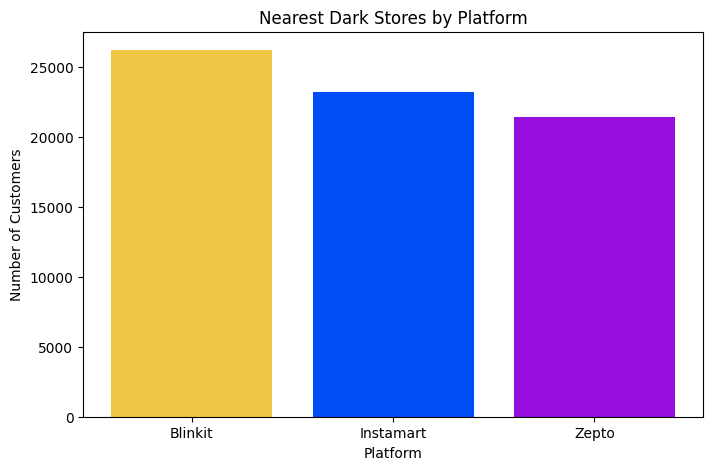

In [213]:
import matplotlib.pyplot as plt

platform_counts = nearest_store_df["platform"].value_counts()

colors = {
    "Blinkit": "#EFC544",
    "Zepto": "#950EDB",
    "Instamart": "#004DF7"
}

bar_colors = [
    colors.get(platform, "#808080")
    for platform in platform_counts.index
]

plt.figure(figsize=(8, 5))

plt.bar(
    platform_counts.index,
    platform_counts.values,
    color=bar_colors
)

plt.title("Nearest Dark Stores by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

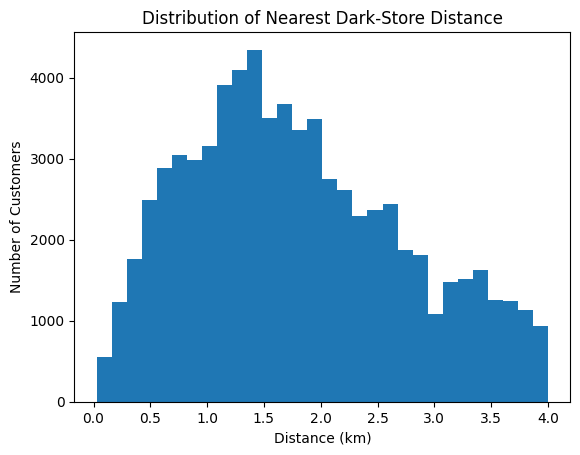

In [208]:
nearest_store_df["distance_km"].plot(
    kind="hist",
    bins=30
)

plt.title("Distribution of Nearest Dark-Store Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Customers")
plt.show()

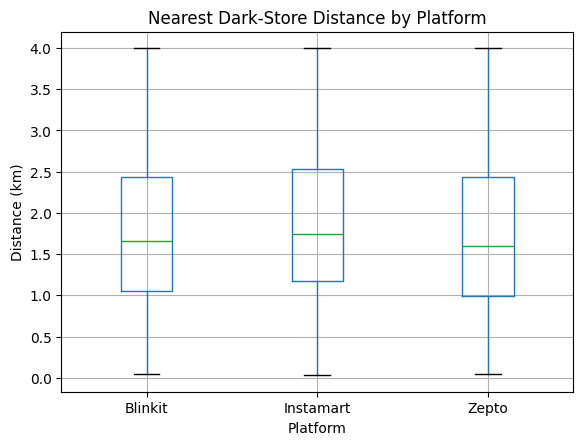

In [209]:
nearest_store_df.boxplot(
    column="distance_km",
    by="platform"
)

plt.title("Nearest Dark-Store Distance by Platform")
plt.suptitle("")
plt.xlabel("Platform")
plt.ylabel("Distance (km)")
plt.show()

In [210]:
avg_distance = (
    nearest_store_df
    .groupby("platform")["distance_km"]
    .mean()
    .sort_values()
)

print(avg_distance)

platform
Zepto        1.755507
Blinkit      1.777321
Instamart    1.861486
Name: distance_km, dtype: float64


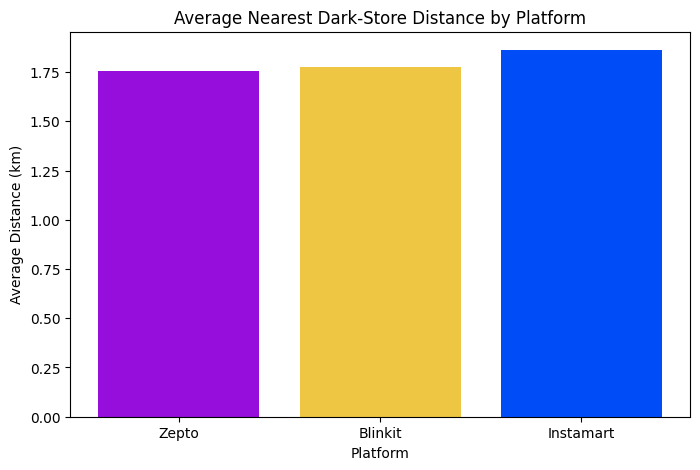

In [214]:
avg_distance = (
    nearest_store_df
    .groupby("platform")["distance_km"]
    .mean()
    .sort_values()
)

bar_colors = [
    colors.get(platform, "#808080")
    for platform in avg_distance.index
]

plt.figure(figsize=(8, 5))

plt.bar(
    avg_distance.index,
    avg_distance.values,
    color=bar_colors
)

plt.title("Average Nearest Dark-Store Distance by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Distance (km)")
plt.xticks(rotation=0)

plt.show()

# Streamlit app

In [217]:
import joblib
import os

model_path = "/kaggle/working/final_eta_model.pkl"

joblib.dump(final_eta_model, model_path)

print("Model saved successfully!")
print("Path:", model_path)
print("File size:", round(os.path.getsize(model_path) / 1024 / 1024, 2), "MB")

Model saved successfully!
Path: /kaggle/working/final_eta_model.pkl
File size: 3.33 MB


In [218]:
loaded_model = joblib.load(model_path)

print("Loaded:", type(loaded_model))

Loaded: <class 'sklearn.pipeline.Pipeline'>


In [216]:
'''If you reached till here 
thank you for reading'''

'If you reached till here \nthank you for reading'